# EDA Weather -- Aviation Operational Review

IMPORTANT UPDATE: The notebook now contains a dedicated EDA block for newly crawled weather columns.

New columns/features covered there: `dew_point_2m`, `weather_code`, `cape`, `lifted_index`, `cloud_cover_low`, `Dew_Point_Spread_C`, `Is_Radiation_Fog_Risk`, `Is_Low_Ceiling_Risk`, `Is_Severe_Convection_Risk`, `Tailwind_Default_Runway_Kt`, `Forced_Runway_Swap_Risk`.

Output tables are saved under `Data crawl/Silver_layer/Audit/eda_weather_reports/` with prefix `06_`.

This notebook focuses on aviation weather operations: visibility thresholds, fog, ceiling, rain/wet runway, wind components, convection, and runway-operation pressure.


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

# Resolve project root whether notebook is opened from project root or 18_24520617_24520636_Source code/.
PROJECT_ROOT = Path.cwd().parent.parent.resolve()

# EDA output directory
REPORT_DIR = PROJECT_ROOT / "18_24520617_24520636_Data" / "Silver_layer" / "Audit" / "eda_weather_reports"
FIG_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPORT_DIR:", REPORT_DIR)

def show_title(text):
    display(Markdown(f"### {text}"))

def save_fig(name, tight=True):
    """Save the current matplotlib figure."""
    path = FIG_DIR / name
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")

def display_and_save(df, name, max_rows=20):
    """Display a DataFrame and save it as CSV."""
    path = REPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=True, encoding="utf-8-sig")
    print(f"Saved table: {path}")
    display(df.head(max_rows))


PROJECT_ROOT: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay
REPORT_DIR: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports


## 0.1. Load data

Chỉnh `DATA_PATH` cho đúng tên file dữ liệu thời tiết của bạn. Notebook hỗ trợ `.csv`, `.xlsx`, `.xls`, `.parquet`.

In [2]:
# =========================
# 0.1. Load data
# =========================
# Default target: preprocessed weather_features_hourly.csv.
# Priority: Silver_layer because weather_preprocessing.py writes the updated aviation schema there.
DATA_CANDIDATES = [
    PROJECT_ROOT / "18_24520617_24520636_Data" / "Silver_layer" / "Features" / "weather_features_hourly.csv",
]

# Set this to a Path/string to override auto-detection. Keep None for auto-detect.
DATA_PATH = None

def resolve_data_path(path=None):
    if path is not None:
        path = Path(path)
        if not path.is_absolute():
            path = PROJECT_ROOT / path
        if path.exists():
            return path
        raise FileNotFoundError(f"DATA_PATH not found: {path}")

    for candidate in DATA_CANDIDATES:
        if candidate.exists():
            return candidate

    tried = "\n".join(str(p) for p in DATA_CANDIDATES)
    raise FileNotFoundError(f"weather_features_hourly.csv not found. Tried:\n{tried}")

def read_data(path):
    path = resolve_data_path(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        data = pd.read_csv(path, na_values=["N/A", "NA", "", "nan", "None"])
    elif suffix in [".xlsx", ".xls"]:
        data = pd.read_excel(path)
    elif suffix == ".parquet":
        data = pd.read_parquet(path)
    else:
        raise ValueError("Unsupported file type. Use .csv, .xlsx, .xls, or .parquet")
    return data, path

df_raw, RESOLVED_DATA_PATH = read_data(DATA_PATH)
df = df_raw.copy()

show_title("18_24520617_24520636_Data preview")
print("18_24520617_24520636_Data path:", RESOLVED_DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.dtypes.to_frame("dtype"))


### Data preview

Data path: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Features/weather_features_hourly.csv
Shape: (6624, 63)


,time,Airport,temperature,precipitation,cloudcover,wind_speed,wind_direction,pressure,humidity,visibility,Visibility_SM,Visibility_Deficit_5KM_M,Visibility_Deficit_3SM_M,Visibility_Severity_Score,Wind_Sector,Wind_Runway_Relative_Angle_Deg,Crosswind_Kmh,Headwind_Kmh,Tailwind_Default_Runway_Kmh,Wind_Kt,Crosswind_Kt,Headwind_Kt,Tailwind_Default_Runway_Kt,Temp_Change_1H_C,Temp_Change_3H_C,Pressure_Change_3H_Hpa,Precip_Cumsum_1H_Mm,Precip_Cumsum_3H_Mm,Precip_Cumsum_6H_Mm,Wind_Gust_Estimate_Kmh,Crosswind_Max_3H_Kmh,Wind_Gust_Estimate_Kt,Crosswind_Max_3H_Kt,Gust_Variation_Kmh,Gust_Variation_Kt,Is_Rain,Is_Heavy_Rain,Is_Strong_Wind,Is_Gale_Wind,Is_Low_Visibility,Is_Fog,Is_Dewpoint_Spread_Le_1_5C,Is_Radiation_Fog_Risk,Is_WMO_Fog_Code,Is_WMO_Rain_Code,Is_WMO_Thunderstorm_Code,Is_Below_3SM_Visibility,Is_Below_1SM_Visibility,Is_Crosswind_10kt,Is_Crosswind_15kt,Is_Crosswind_20kt,Is_Tailwind_Default_Runway_5kt,Is_Low_Ceiling_Risk,Is_Severe_Convection_Risk,Is_Freezing,Is_Extreme_Heat,Is_Thunderstorm_Risk,Convective_Severity_Score,Runway_Wet_Risk,Forced_Runway_Swap_Risk,Runway_Ice_Risk,Weather_Delay_Risk_Score,Aviation_Operational_Risk_Score
0,2025-12-15 00:00:00,DAD,22.9,0.2,33,15.8,38,1016.5,83,12400.0,7.71,0.0,0.0,0,NE,48.0,11.74,10.57,0.0,8.53,6.34,5.71,0.0,NaN,NaN,NaN,0.2,0.2,0.2,15.8,11.74,8.53,6.34,0.0,0.00,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1
1,2025-12-15 01:00:00,DAD,22.2,0.3,100,12.6,31,1016.4,87,10840.0,6.74,0.0,0.0,0,NE,41.0,8.27,9.51,0.0,6.80,4.46,5.13,0.0,-0.7,NaN,NaN,0.3,0.5,0.5,15.8,11.74,8.53,6.34,3.2,1.73,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,2
2,2025-12-15 02:00:00,DAD,22.0,0.3,100,14.2,33,1016.2,88,10760.0,6.69,0.0,0.0,0,NE,43.0,9.68,10.39,0.0,7.67,5.23,5.61,0.0,-0.2,NaN,NaN,0.3,0.8,0.8,15.8,11.74,8.53,6.34,1.6,0.86,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,2
3,2025-12-15 03:00:00,DAD,22.0,0.2,98,11.8,6,1015.7,88,10320.0,6.41,0.0,0.0,0,N,16.0,3.25,11.34,0.0,6.37,1.76,6.12,0.0,0.0,-0.9,-0.8,0.2,0.8,1.0,14.2,9.68,7.67,5.23,2.4,1.30,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,2
4,2025-12-15 04:00:00,DAD,22.0,0.1,100,9.4,1,1015.6,90,10380.0,6.45,0.0,0.0,0,N,11.0,1.79,9.23,0.0,5.08,0.97,4.98,0.0,0.0,-0.2,-0.8,0.1,0.6,1.1,14.2,9.68,7.67,5.23,4.8,2.59,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,2


,dtype
time,str
Airport,str
temperature,float64
precipitation,float64
cloudcover,int64
wind_speed,float64
wind_direction,int64
pressure,float64
humidity,int64
visibility,float64


## 0.2. Tự nhận diện cột quan trọng

Nếu notebook nhận diện sai tên cột, chỉnh trực tiếp trong `USER_COLS`.

In [3]:
# =========================
# 0.2. Infer / override column names
# =========================

# Nếu tên cột trong data của bạn khác, điền thủ công vào đây.
# Ví dụ: USER_COLS["datetime"] = "time"
USER_COLS = {
    "datetime": None,
    "airport": None,
    "risk": None,
    "precip": None,
    "visibility": None,
    "temperature": None,
    "humidity": None,
    "cloudcover": None,
    "wind_speed": None,
    "headwind": None,
    "crosswind": None,
    "is_rain": None,
    "is_thunderstorm": None,
    "is_low_visibility": None,
    "is_fog": None,
    "is_strong_wind": None,
    "is_gale_wind": None,
    "is_freezing": None,
    "runway_ice_risk": None,
    "runway_wet_risk": None,
    "is_heavy_rain": None,
    "precip_cumsum_1h": None,
    "precip_cumsum_3h": None,
    "precip_cumsum_6h": None,
    "temp_change": None,
}

def norm_col(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def find_col(candidates, required=False):
    """Tìm cột theo danh sách tên ứng viên, ưu tiên exact-normalized rồi contains."""
    cols = list(df.columns)
    norm_to_col = {norm_col(c): c for c in cols}

    for cand in candidates:
        n = norm_col(cand)
        if n in norm_to_col:
            return norm_to_col[n]

    for cand in candidates:
        n = norm_col(cand)
        for col in cols:
            cn = norm_col(col)
            if n and n in cn:
                return col

    if required:
        raise KeyError(f"Không tìm thấy cột nào khớp với: {candidates}")
    return None

def infer_datetime_col():
    # Ưu tiên tên rõ ràng
    c = find_col(["datetime", "date_time", "timestamp", "time", "valid_time", "observation_time", "date"], required=False)
    if c is not None:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() >= 0.75:
            return c

    # Thử parse các cột object có vẻ là thời gian
    for col in df.columns:
        if df[col].dtype == "object":
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() >= 0.80:
                return col
    return None

CANDIDATES = {
    "airport": ["airport", "airport_code", "iata", "station", "location", "site"],
    "risk": ["Weather_Delay_Risk_Score", "weather delay risk score", "risk_score", "delay_risk_score", "risk"],
    "precip": ["precipitation (1h)", "precipitation_1h", "precip_1h", "precipitation", "rain_mm", "rain"],
    "visibility": ["visibility", "visibility_m", "vis", "vis_m"],
    "temperature": ["temperature", "temp", "temperature_2m"],
    "humidity": ["humidity", "relative_humidity", "rh"],
    "cloudcover": ["cloudcover", "cloud_cover", "cloud cover", "clouds"],
    "wind_speed": ["wind_speed", "windspeed", "wind speed", "wind_speed_kmh", "Wind_Speed_Kmh"],
    "headwind": ["Headwind_Kmh", "headwind", "head_wind"],
    "crosswind": ["Crosswind_Kmh", "crosswind", "cross_wind"],
    "is_rain": ["Is_Rain", "is_rain", "rain_flag"],
    "is_thunderstorm": ["Is_Thunderstorm_Risk", "thunderstorm_risk", "is_thunderstorm"],
    "is_low_visibility": ["Is_Low_Visibility", "low_visibility", "is_low_visibility"],
    "is_fog": ["Is_Fog", "is_fog", "fog"],
    "is_strong_wind": ["Is_Strong_Wind", "strong_wind", "is_strong_wind"],
    "is_gale_wind": ["Is_Gale_Wind", "gale_wind", "is_gale_wind"],
    "is_freezing": ["Is_Freezing", "is_freezing", "freezing"],
    "runway_ice_risk": ["Runway_Ice_Risk", "runway_ice"],
    "runway_wet_risk": ["Runway_Wet_Risk", "runway_wet"],
    "is_heavy_rain": ["Is_Heavy_Rain", "heavy_rain", "is_heavy_rain"],
    "precip_cumsum_1h": ["Precip_Cumsum_1H_Mm", "precip_cumsum_1h", "precip_sum_1h"],
    "precip_cumsum_3h": ["Precip_Cumsum_3H_Mm", "precip_cumsum_3h", "precip_sum_3h"],
    "precip_cumsum_6h": ["Precip_Cumsum_6H_Mm", "precip_cumsum_6h", "precip_sum_6h"],
    "temp_change": ["Temp_Change", "temperature_change", "temp_delta"],
}

COLS = {}
COLS["datetime"] = USER_COLS["datetime"] or infer_datetime_col()

for key, candidates in CANDIDATES.items():
    COLS[key] = USER_COLS[key] or find_col(candidates, required=False)

# Require 2 cột lõi
if COLS["datetime"] is None:
    raise ValueError("Không tìm thấy cột thời gian. Hãy set USER_COLS['datetime'] thủ công.")
if COLS["risk"] is None:
    raise ValueError("Không tìm thấy cột Weather_Delay_Risk_Score / risk. Hãy set USER_COLS['risk'] thủ công.")

# Nếu không có airport, tạo airport giả để code vẫn chạy
if COLS["airport"] is None:
    df["_Airport"] = "ALL"
    COLS["airport"] = "_Airport"

# Parse datetime
df[COLS["datetime"]] = pd.to_datetime(df[COLS["datetime"]], errors="coerce")
df = df.dropna(subset=[COLS["datetime"]]).sort_values([COLS["airport"], COLS["datetime"]]).reset_index(drop=True)

# Ép numeric cho các cột số quan trọng
for key, col in COLS.items():
    if col is not None and key not in ["datetime", "airport"] and col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Feature thời gian
df["_date"] = df[COLS["datetime"]].dt.date
df["_month"] = df[COLS["datetime"]].dt.to_period("M").astype(str)
df["_hour"] = df[COLS["datetime"]].dt.hour
df["_weekday"] = df[COLS["datetime"]].dt.day_name()

show_title("Column mapping")
mapping = pd.DataFrame.from_dict(COLS, orient="index", columns=["mapped_column"])
display(mapping)
mapping.to_csv(REPORT_DIR / "column_mapping.csv")

### Column mapping

,mapped_column
datetime,time
airport,Airport
risk,Weather_Delay_Risk_Score
precip,precipitation
visibility,visibility
temperature,temperature
humidity,humidity
cloudcover,cloudcover
wind_speed,wind_speed
headwind,Headwind_Kmh


## 0.3. Bổ sung feature cơ bản nếu dataset chưa có

Cell này tạo thêm một số feature nếu thiếu: `Is_Rain`, `Is_Low_Visibility`, `Visibility_Capped_Flag`, `Precip_Cumsum_1H/3H/6H`, `Temp_Change`.

In [4]:
# =========================
# 0.3. Create missing helper features
# =========================

airport_col = COLS["airport"]
dt_col = COLS["datetime"]
risk_col = COLS["risk"]
precip_col = COLS["precip"]
vis_col = COLS["visibility"]
temp_col = COLS["temperature"]

def add_binary_col(name, condition):
    if name not in df.columns:
        df[name] = condition.astype(int)
    return name

# Is_Rain
if COLS["is_rain"] is None and precip_col is not None:
    COLS["is_rain"] = add_binary_col("Is_Rain_AUTO", df[precip_col].fillna(0) > 0)

# Is_Low_Visibility
if COLS["is_low_visibility"] is None and vis_col is not None:
    COLS["is_low_visibility"] = add_binary_col("Is_Low_Visibility_AUTO_10000m", df[vis_col].fillna(np.inf) < 10000)

# Visibility capped flag
if vis_col is not None:
    # Theo kế hoạch: cap thường gặp là 24,140m.
    # Nếu data không có 24,140, dùng max observed để kiểm tra artifact.
    observed_max = df[vis_col].max(skipna=True)
    cap_value = 24140 if (df[vis_col].eq(24140).any() or abs(observed_max - 24140) < 1e-6) else observed_max
    df["Visibility_Capped_Flag"] = df[vis_col].ge(cap_value).astype(int)
else:
    cap_value = None

# Precip cumsum 1H/3H/6H nếu thiếu
if precip_col is not None:
    for window in [1, 3, 6]:
        key = f"precip_cumsum_{window}h"
        existing = COLS.get(key)
        if existing is None:
            new_col = f"Precip_Cumsum_{window}H_Mm_AUTO"
            # rolling theo số dòng; dataset hourly complete thì tương ứng rolling theo giờ
            df[new_col] = (
                df.groupby(airport_col)[precip_col]
                  .transform(lambda s: s.fillna(0).rolling(window=window, min_periods=1).sum())
            )
            COLS[key] = new_col

# Temp change nếu thiếu
if COLS["temp_change"] is None and temp_col is not None:
    new_col = "Temp_Change_AUTO"
    df[new_col] = df.groupby(airport_col)[temp_col].diff()
    COLS["temp_change"] = new_col

show_title("Sau khi bổ sung feature")
display(pd.DataFrame.from_dict(COLS, orient="index", columns=["mapped_column"]))
print("Shape:", df.shape)

### Sau khi bổ sung feature

,mapped_column
datetime,time
airport,Airport
risk,Weather_Delay_Risk_Score
precip,precipitation
visibility,visibility
temperature,temperature
humidity,humidity
cloudcover,cloudcover
wind_speed,wind_speed
headwind,Headwind_Kmh


Shape: (6624, 68)


# Bước 1 — Sanity check & artifact check

Mục tiêu:
- Kiểm tra shape, missing values, duplicate.
- Kiểm tra đủ giờ theo từng sân bay.
- Kiểm tra visibility bị capped ở 24,140m.
- Kiểm tra consistency của feature logic: strong wind, fog, low visibility.
- Tìm zero-variance / near-zero-variance features.

In [5]:
# =========================
# 1. Sanity check
# =========================

show_title("1.1. Tổng quan dữ liệu")
overview = pd.DataFrame({
    "metric": ["rows", "columns", "airports", "start_time", "end_time", "days"],
    "value": [
        len(df),
        df.shape[1],
        df[airport_col].nunique(),
        df[dt_col].min(),
        df[dt_col].max(),
        (df[dt_col].max() - df[dt_col].min()).days + 1
    ]
})
display_and_save(overview, "01_overview")

show_title("1.2. Missing values")
missing = df.isna().sum().sort_values(ascending=False)
missing_rate = (df.isna().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({"missing_count": missing, "missing_rate_pct": missing_rate})
missing_table = missing_table[missing_table["missing_count"] > 0]
display_and_save(missing_table, "01_missing_values")

show_title("1.3. Duplicate rows")
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)
if dup_count > 0:
    display(df[df.duplicated()].head())

### 1.1. Tổng quan dữ liệu

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/01_overview.csv


,metric,value
0,rows,6624
1,columns,68
2,airports,3
3,start_time,2025-12-15 00:00:00
4,end_time,2026-03-16 23:00:00
5,days,92


### 1.2. Missing values

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/01_missing_values.csv


,missing_count,missing_rate_pct
Temp_Change_3H_C,9,0.13587
Pressure_Change_3H_Hpa,9,0.13587
Temp_Change_1H_C,3,0.04529


### 1.3. Duplicate rows

Duplicate rows: 0


In [6]:
# =========================
# 1.4. Hourly completeness
# =========================

def hourly_completeness_table(data, airport_col, dt_col):
    rows = []
    missing_examples = {}
    for airport, g in data.groupby(airport_col):
        times = pd.DatetimeIndex(g[dt_col].drop_duplicates().sort_values())
        if len(times) == 0:
            continue
        full_range = pd.date_range(times.min(), times.max(), freq="h")
        missing_times = full_range.difference(times)
        expected_hours = len(full_range)
        actual_hours = len(times)
        completeness = actual_hours / expected_hours if expected_hours else np.nan

        rows.append({
            "airport": airport,
            "start": times.min(),
            "end": times.max(),
            "expected_hours": expected_hours,
            "actual_hours": actual_hours,
            "missing_hours": len(missing_times),
            "completeness_pct": completeness * 100,
        })
        if len(missing_times) > 0:
            missing_examples[airport] = list(missing_times[:10])
    return pd.DataFrame(rows), missing_examples

hourly_table, missing_examples = hourly_completeness_table(df, airport_col, dt_col)
display_and_save(hourly_table, "01_hourly_completeness")
if missing_examples:
    print("Ví dụ missing times:")
    for airport, ex in missing_examples.items():
        print(airport, ex)
else:
    print("Không phát hiện missing hour theo từng sân bay.")

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/01_hourly_completeness.csv


,airport,start,end,expected_hours,actual_hours,missing_hours,completeness_pct
0,DAD,2025-12-15,2026-03-16 23:00:00,2208,2208,0,100.0
1,HAN,2025-12-15,2026-03-16 23:00:00,2208,2208,0,100.0
2,SGN,2025-12-15,2026-03-16 23:00:00,2208,2208,0,100.0


Không phát hiện missing hour theo từng sân bay.


### 1.5. Visibility capped artifact

Visibility cap value used: 24140
Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/01_visibility_capping_by_airport.csv


,visibility_min,visibility_p25,visibility_median,visibility_p75,visibility_max,capped_hours,total_hours,capped_rate_pct
Airport,,,,,,,,
SGN,3600.0,24140.0,24140.0,24140.0,24140.0,2120,2208,96.014493
HAN,5040.0,24140.0,24140.0,24140.0,24140.0,2050,2208,92.844203
DAD,3960.0,21800.0,24140.0,24140.0,24140.0,1377,2208,62.364130


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/01_visibility_distribution.png


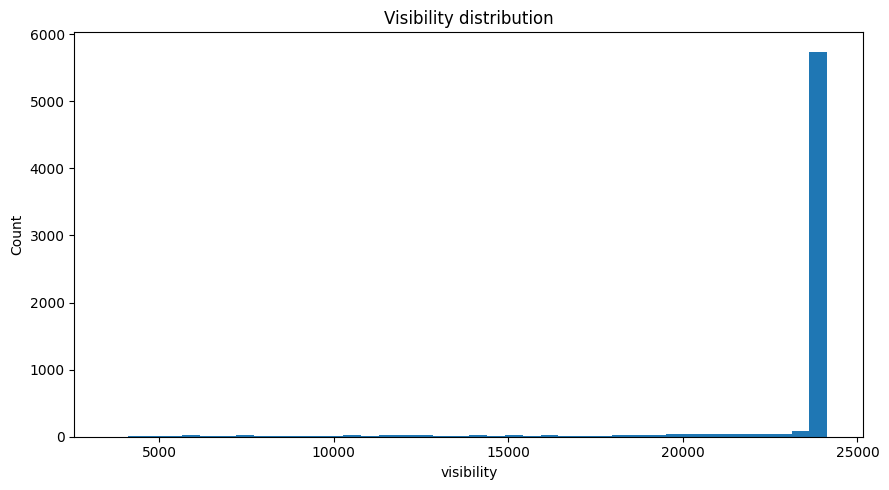

Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/01_visibility_distribution_excluding_cap.png


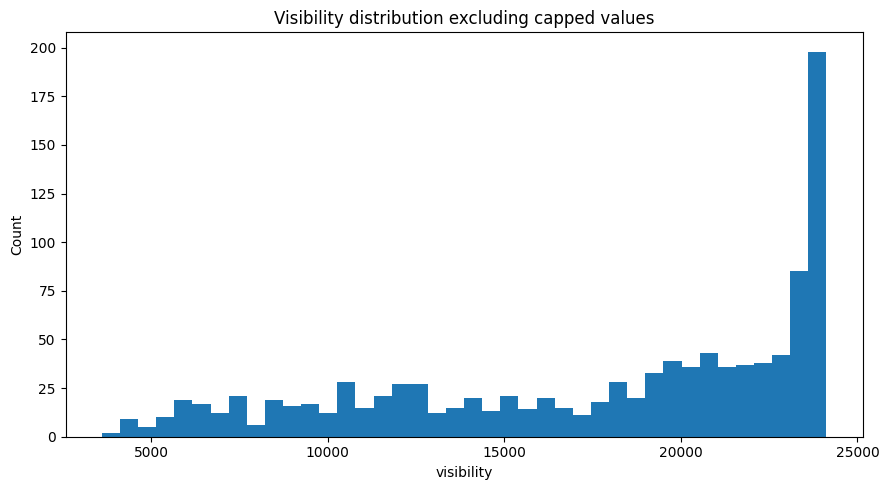

In [7]:
# =========================
# 1.5. Visibility capped artifact
# =========================

if vis_col is not None:
    show_title("1.5. Visibility capped artifact")
    print("Visibility cap value used:", cap_value)

    vis_summary = df.groupby(airport_col).agg(
        visibility_min=(vis_col, "min"),
        visibility_p25=(vis_col, lambda x: x.quantile(0.25)),
        visibility_median=(vis_col, "median"),
        visibility_p75=(vis_col, lambda x: x.quantile(0.75)),
        visibility_max=(vis_col, "max"),
        capped_hours=("Visibility_Capped_Flag", "sum"),
        total_hours=("Visibility_Capped_Flag", "size"),
        capped_rate_pct=("Visibility_Capped_Flag", lambda x: x.mean() * 100),
    ).sort_values("capped_rate_pct", ascending=False)
    display_and_save(vis_summary, "01_visibility_capping_by_airport")

    # Histogram visibility, toàn bộ data
    plt.figure(figsize=(9, 5))
    plt.hist(df[vis_col].dropna(), bins=40)
    plt.title("Visibility distribution")
    plt.xlabel(vis_col)
    plt.ylabel("Count")
    save_fig("01_visibility_distribution.png")
    plt.show()

    # Histogram visibility excluding capped values
    noncap = df.loc[df["Visibility_Capped_Flag"] == 0, vis_col].dropna()
    if len(noncap) > 0:
        plt.figure(figsize=(9, 5))
        plt.hist(noncap, bins=40)
        plt.title("Visibility distribution excluding capped values")
        plt.xlabel(vis_col)
        plt.ylabel("Count")
        save_fig("01_visibility_distribution_excluding_cap.png")
        plt.show()
else:
    print("Không có cột visibility, bỏ qua kiểm tra capping.")

### Nhận xét:
Đối với SGN và HAN: 

    + Phân phối visibility lệch phải, với tỷ lệ Capped cực cao: Tại SGN (96%) và HAN (92.8%), gần như toàn bộ thời gian cảm biến chỉ báo một con số duy nhất: 24,140m.

    + Vấn đề: Trong thực tế, tầm nhìn có thể là 30km, 50km hoặc 100km vào những ngày trời trong, nhưng hệ thống ghi nhận đã "cắt cụt" tất cả về một mức. Điều này biến cột visibility thành một biến gần như là Hằng số (Constant) cho hai sân bay này.

Đối với DAD: Capped Rate (62.36%): DAD có tỷ lệ bị chặn thấp hơn hẳn SGN và HAN.

    + Giá trị P25 (21,800m): Trong khi SGN và HAN đến tận mức 25% vẫn đang ở mức "kịch trần" (24,140m), thì DAD đã bắt đầu thấy sự sụt giảm tầm nhìn.

    + Insight: Điều này củng cố thêm nhận định từ các bước trước: DAD là sân bay chịu ảnh hưởng của các hiện tượng giảm tầm nhìn (mưa dầm, mây thấp) nhiều nhất trong giai đoạn này.

In [8]:
# =========================
# 1.6. Logic consistency checks
# =========================

show_title("1.6. Logic consistency checks")

logic_rows = []

# Is_Strong_Wind vs wind speed
if COLS["is_strong_wind"] is not None and COLS["wind_speed"] is not None:
    strong_col = COLS["is_strong_wind"]
    wind_col = COLS["wind_speed"]
    logic_rows.append({
        "check": "Is_Strong_Wind summary",
        "result": f"{strong_col}=1 hours: {int(df[strong_col].fillna(0).sum())}, max {wind_col}: {df[wind_col].max():.2f}"
    })

    # Threshold tham khảo: 30 kt ≈ 55.56 km/h
    threshold_30kt_kmh = 30 * 1.852
    potential_strong = df[wind_col] >= threshold_30kt_kmh
    logic_rows.append({
        "check": "Wind >= 30kt equivalent",
        "result": f"hours >= {threshold_30kt_kmh:.1f} km/h: {int(potential_strong.sum())}"
    })

# Is_Fog vs Low Visibility
if COLS["is_fog"] is not None and COLS["is_low_visibility"] is not None:
    fog_col = COLS["is_fog"]
    lowvis_col = COLS["is_low_visibility"]
    fog_sum = int(df[fog_col].fillna(0).sum())
    lowvis_sum = int(df[lowvis_col].fillna(0).sum())
    lowvis_no_fog = int(((df[lowvis_col].fillna(0) == 1) & (df[fog_col].fillna(0) == 0)).sum())
    logic_rows.append({
        "check": "Is_Fog vs Is_Low_Visibility",
        "result": f"fog hours={fog_sum}, low visibility hours={lowvis_sum}, lowvis but no fog={lowvis_no_fog}"
    })

logic_table = pd.DataFrame(logic_rows)
display_and_save(logic_table, "01_logic_checks")

### 1.6. Logic consistency checks

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/01_logic_checks.csv


,check,result
0,Is_Strong_Wind summary,"Is_Strong_Wind=1 hours: 0, max wind_speed: 27.50"
1,Wind >= 30kt equivalent,hours >= 55.6 km/h: 0
2,Is_Fog vs Is_Low_Visibility,"fog hours=0, low visibility hours=14, lowvis b..."


### Nhận xét:

    + Lỗ hổng Logic (Is_Fog): Phát hiện 14 giờ tầm nhìn thấp nhưng 0 giờ có sương mù. Có thể logic tính sương mù đang sai hoặc quá hẹp. Cần sửa lại công thức này vì sương mù là nguyên nhân gây trễ chuyến cực lớn tại Nội Bài.

    + Gió không quá mạnh: Không có giờ nào gió vượt 30 hải lý (55 km/h). Gió tại Việt Nam giai đoạn này chỉ ở mức trung bình, ảnh hưởng trễ chuyến sẽ nằm ở Gió ngang (Crosswind) chứ không phải bão lớn.

In [9]:
# =========================
# 1.7. Zero variance / near-zero variance
# =========================

show_title("1.7. Zero-variance and near-zero-variance features")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
nunique = df[numeric_cols].nunique(dropna=False).sort_values()

zero_variance = nunique[nunique <= 1].to_frame("nunique")
display_and_save(zero_variance, "01_zero_variance_features")

nzv_rows = []
for col in numeric_cols:
    vc = df[col].value_counts(dropna=False, normalize=True)
    if len(vc) > 1:
        top_rate = vc.iloc[0]
        # near-zero variance: 1 giá trị chiếm >= 99.5%
        if top_rate >= 0.995:
            nzv_rows.append({
                "feature": col,
                "nunique": df[col].nunique(dropna=False),
                "top_value": vc.index[0],
                "top_rate_pct": top_rate * 100
            })

near_zero_variance = pd.DataFrame(nzv_rows).sort_values("top_rate_pct", ascending=False)
display_and_save(near_zero_variance, "01_near_zero_variance_features")

### 1.7. Zero-variance and near-zero-variance features

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/01_zero_variance_features.csv


,nunique
Is_Crosswind_15kt,1
Is_Gale_Wind,1
Is_Strong_Wind,1
Is_Radiation_Fog_Risk,1
Is_WMO_Fog_Code,1
Is_WMO_Rain_Code,1
Is_WMO_Thunderstorm_Code,1
Is_Below_1SM_Visibility,1
Is_Fog,1
Is_Crosswind_20kt,1


Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/01_near_zero_variance_features.csv


,feature,nunique,top_value,top_rate_pct
3,Is_Heavy_Rain,2,0.0,99.864130
1,Visibility_Deficit_3SM_M,12,0.0,99.803744
5,Is_Below_3SM_Visibility,2,0.0,99.803744
6,Is_Extreme_Heat,2,0.0,99.803744
0,Visibility_Deficit_5KM_M,13,0.0,99.788647
2,Visibility_Severity_Score,3,0.0,99.788647
4,Is_Low_Visibility,2,0.0,99.788647


### Nhận xét:

- 5 cột Is_Freezing, Is_Strong_Wind, Is_Fog, Runway_Ice_Risk, Is_Gale_Wind chỉ có duy nhất 1 giá trị (hằng số). Hành động: Loại bỏ ngay vì chúng không cung cấp thông tin để mô hình phân loại.

- Sự kiện cực hiếm (Near-zero-variance): Is_Heavy_Rain, Is_Extreme_Heat, Is_Low_Visibility có tỷ lệ xuất hiện cực thấp (< 0.22%, tức chỉ khoảng 9-14 giờ trên tổng 6,624 giờ) => biến cố hiếm nhưng ảnh hưởng lớn 

# Bước 2 — Time-series & seasonal trend

Mục tiêu:
- Vẽ trend theo ngày/tháng của `Weather_Delay_Risk_Score`, mưa, dông.
- So sánh seasonal pattern giữa các sân bay.
- Kiểm tra hourly pattern, đặc biệt peak mưa sáng sớm.

### 2.1. Daily trend by airport

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/02_daily_trend.csv


,Airport,_date,risk_mean,risk_max,risk_positive_rate,precip_mean,precip_sum,rain_rate,thunderstorm_rate
0,DAD,2025-12-15,0.875000,1,0.875000,0.262500,6.3,0.958333,0.875000
1,DAD,2025-12-16,0.666667,1,0.666667,0.241667,5.8,0.750000,0.666667
2,DAD,2025-12-17,0.750000,1,0.750000,0.208333,5.0,0.875000,0.750000
3,DAD,2025-12-18,0.083333,1,0.083333,0.108333,2.6,0.583333,0.083333
4,DAD,2025-12-19,0.291667,1,0.291667,0.091667,2.2,0.416667,0.291667
5,DAD,2025-12-20,0.458333,1,0.458333,0.216667,5.2,0.583333,0.458333
6,DAD,2025-12-21,0.916667,1,0.916667,0.991667,23.8,1.000000,0.875000
7,DAD,2025-12-22,0.458333,1,0.458333,0.437500,10.5,0.875000,0.458333
8,DAD,2025-12-23,0.375000,1,0.375000,0.100000,2.4,0.625000,0.375000
9,DAD,2025-12-24,0.333333,1,0.333333,0.091667,2.2,0.416667,0.333333


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/02_daily_risk_mean_by_airport.png


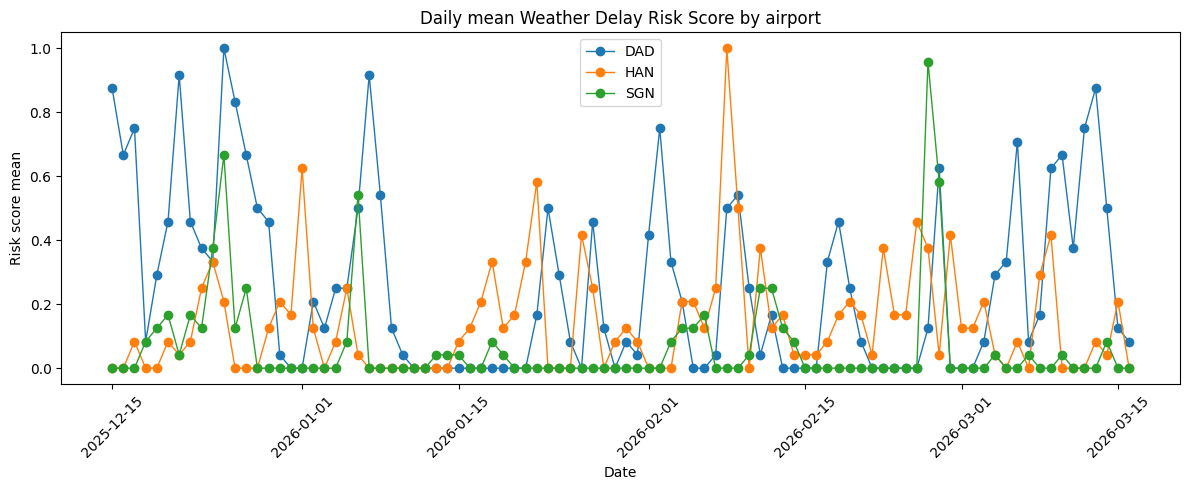

Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/02_daily_precip_sum_by_airport.png


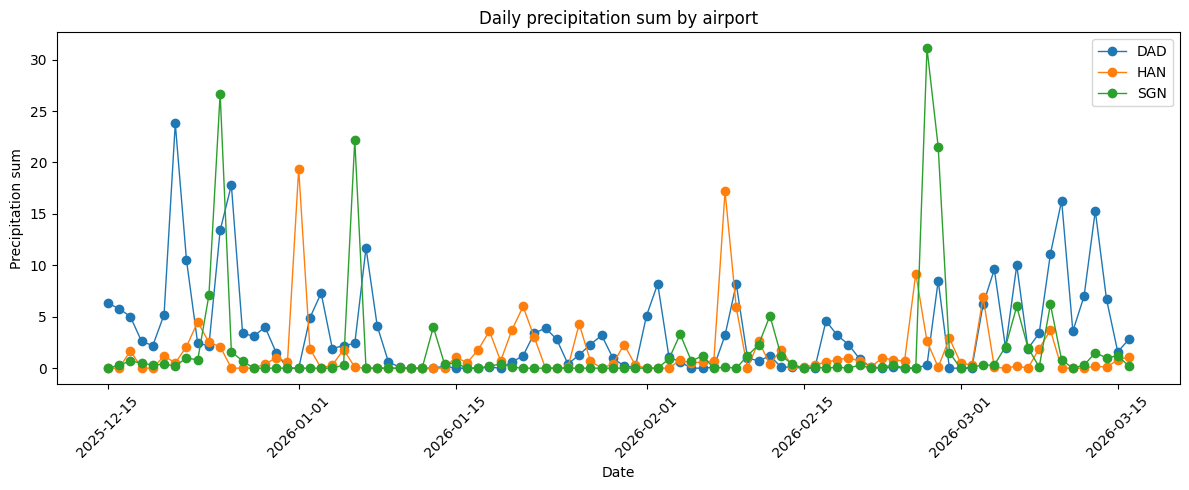

In [10]:
# =========================
# 2. Time-series and seasonal trend
# =========================

show_title("2.1. Daily trend by airport")

agg_dict = {
    "risk_mean": (risk_col, "mean"),
    "risk_max": (risk_col, "max"),
    "risk_positive_rate": (risk_col, lambda x: (x > 0).mean()),
}
if precip_col is not None:
    agg_dict.update({
        "precip_mean": (precip_col, "mean"),
        "precip_sum": (precip_col, "sum"),
    })
if COLS["is_rain"] is not None:
    agg_dict["rain_rate"] = (COLS["is_rain"], "mean")
if COLS["is_thunderstorm"] is not None:
    agg_dict["thunderstorm_rate"] = (COLS["is_thunderstorm"], "mean")

daily = df.groupby([airport_col, "_date"]).agg(**agg_dict).reset_index()
daily["_date"] = pd.to_datetime(daily["_date"])

display_and_save(daily, "02_daily_trend", max_rows=10)

# Plot daily risk
plt.figure(figsize=(12, 5))
for airport, g in daily.groupby(airport_col):
    plt.plot(g["_date"], g["risk_mean"], marker="o", linewidth=1, label=str(airport))
plt.title("Daily mean Weather Delay Risk Score by airport")
plt.xlabel("Date")
plt.ylabel("Risk score mean")
plt.legend()
plt.xticks(rotation=45)
save_fig("02_daily_risk_mean_by_airport.png")
plt.show()

# Plot daily precipitation if available
if precip_col is not None:
    plt.figure(figsize=(12, 5))
    for airport, g in daily.groupby(airport_col):
        plt.plot(g["_date"], g["precip_sum"], marker="o", linewidth=1, label=str(airport))
    plt.title("Daily precipitation sum by airport")
    plt.xlabel("Date")
    plt.ylabel("Precipitation sum")
    plt.legend()
    plt.xticks(rotation=45)
    save_fig("02_daily_precip_sum_by_airport.png")
    plt.show()

### Nhận xét:
- DAD tồn tại Risk Cluster, nghĩa là DAD không có ngày nào Risk = 0: Trong suốt 10 ngày, ngày nào cũng có ít nhất một giờ bị đánh dấu rủi ro (risk_max luôn bằng 1).

    + Đỉnh điểm rủi ro (21/12): Đây là ngày "tồi tệ" nhất với risk_mean đạt 0.916 và risk_positive_rate là 0.875. Nghĩa là trong 24 giờ của ngày này, có tới 21 giờ máy bay đối mặt với rủi ro thời tiết.

    + Tính liên tục: Các ngày 15, 16, 17 và 21 có chỉ số rủi ro rất cao. Điều này xác nhận lý thuyết: Thời tiết xấu ở DAD giai đoạn này không diễn ra chớp nhoáng mà kéo dài theo đợt (mưa dầm).

- Tương quan giữa mưa và rủi ro: 

    + Rain Rate vs Risk Positive Rate: Hai chỉ số này biến thiên gần như đồng nhất. Ví dụ ngày 21/12, rain_rate là 1.0 (mưa cả ngày) thì rủi ro cũng bao phủ 87.5% thời gian.

    + Cường độ mưa: Ngày 21/12 có precip_sum lên tới 23.8mm (mưa to). So với ngày 15/12 (precip_sum 6.3mm), dù cả hai đều có rủi ro cao, nhưng mức độ ảnh hưởng đến khả năng thoát nước đường băng và tầm nhìn của ngày 21 sẽ nghiêm trọng hơn.

- Yếu tố "Thunderstorm": Hiện tại, "Thunderstorm" là yếu tố tác động Risk_Score cao nhất

- Ngày 18, 19, 23, 24: 
    + 18/12: rain_rate khá cao (0.58) nhưng risk_positive_rate và thunderstorm_rate chỉ có 0.08
    
    => Phân biệt được Mưa phùn/Mưa nhẹ (ít rủi ro trễ chuyến) và Mưa dông (rủi ro cao)

Gợi ý: Biến tích lũy (Days_of_Continuous_Rain), Độ trễ(Time-lag)


### 2.2. Monthly seasonal profile

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/02_monthly_profile.csv


,Airport,_month,hours,risk_mean,risk_positive_rate_pct,risk_ge2_rate_pct,precip_mean,precip_sum,rain_rate_pct,thunderstorm_rate_pct
0,DAD,2025-12,408,0.512255,51.225490,0.000000,0.267647,109.2,66.911765,50.980392
1,DAD,2026-01,744,0.151882,15.188172,0.000000,0.075134,55.9,29.838710,15.188172
2,DAD,2026-02,672,0.183036,18.303571,0.000000,0.073810,49.6,27.976190,18.303571
3,DAD,2026-03,384,0.354167,33.333333,2.083333,0.253906,97.5,54.166667,33.072917
4,HAN,2025-12,408,0.093137,9.313725,0.000000,0.040686,16.6,16.421569,9.313725
5,HAN,2026-01,744,0.130376,12.903226,0.134409,0.069892,52.0,15.725806,12.903226
6,HAN,2026-02,672,0.205357,20.535714,0.000000,0.076786,51.6,22.470238,20.535714
7,HAN,2026-03,384,0.101562,10.156250,0.000000,0.041146,15.8,11.979167,10.156250
8,SGN,2025-12,408,0.125000,11.029412,1.225490,0.098775,40.3,14.705882,11.029412
9,SGN,2026-01,744,0.028226,2.553763,0.268817,0.037769,28.1,4.435484,2.553763


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/02_monthly_risk_mean_by_airport.png


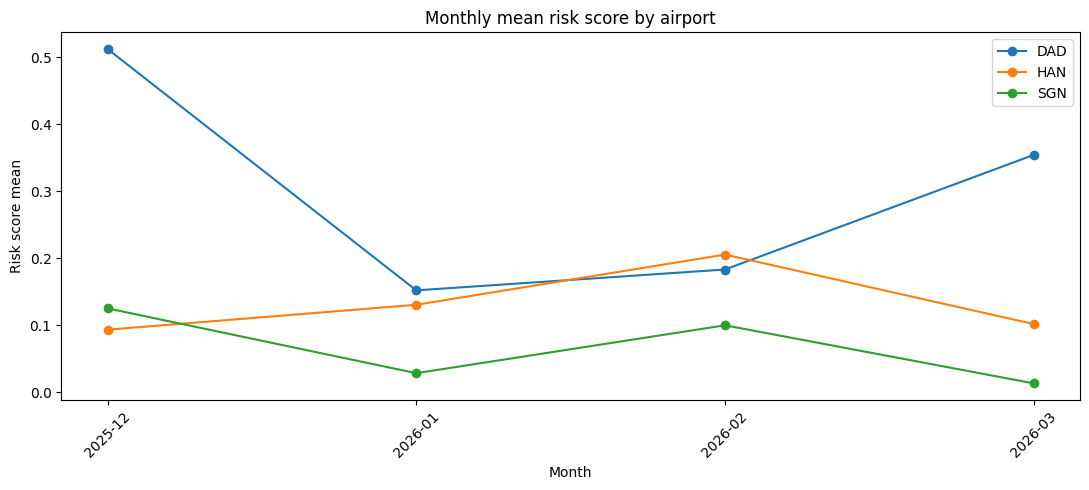

Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/02_monthly_rain_rate_by_airport.png


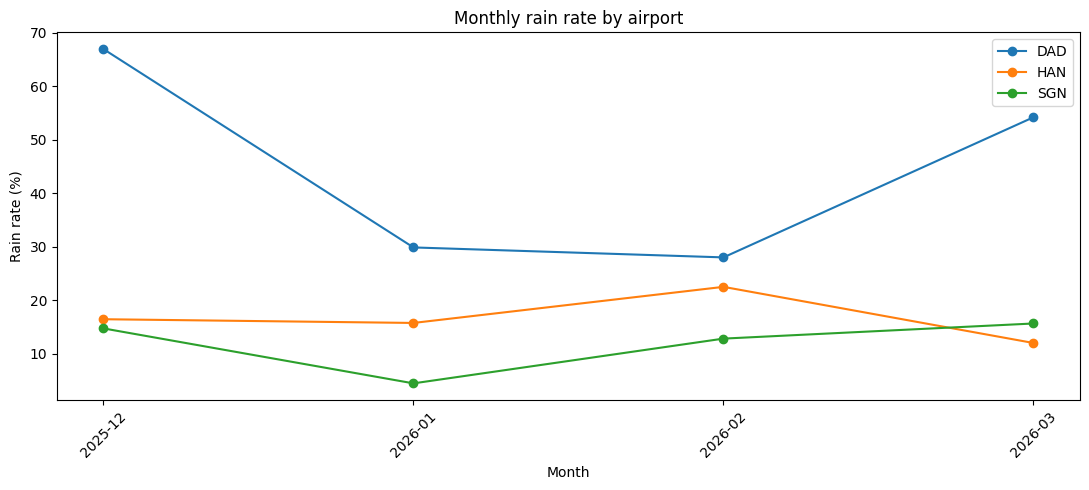

In [11]:
# =========================
# 2.2. Monthly / seasonal profile
# =========================

show_title("2.2. Monthly seasonal profile")

monthly_agg = {
    "hours": (risk_col, "size"),
    "risk_mean": (risk_col, "mean"),
    "risk_positive_rate_pct": (risk_col, lambda x: (x > 0).mean() * 100),
    "risk_ge2_rate_pct": (risk_col, lambda x: (x >= 2).mean() * 100),
}
if precip_col is not None:
    monthly_agg["precip_mean"] = (precip_col, "mean")
    monthly_agg["precip_sum"] = (precip_col, "sum")
if COLS["is_rain"] is not None:
    monthly_agg["rain_rate_pct"] = (COLS["is_rain"], lambda x: x.mean() * 100)
if COLS["is_thunderstorm"] is not None:
    monthly_agg["thunderstorm_rate_pct"] = (COLS["is_thunderstorm"], lambda x: x.mean() * 100)

monthly = df.groupby([airport_col, "_month"]).agg(**monthly_agg).reset_index()
display_and_save(monthly, "02_monthly_profile", max_rows=30)

plt.figure(figsize=(11, 5))
for airport, g in monthly.groupby(airport_col):
    plt.plot(g["_month"], g["risk_mean"], marker="o", label=str(airport))
plt.title("Monthly mean risk score by airport")
plt.xlabel("Month")
plt.ylabel("Risk score mean")
plt.legend()
plt.xticks(rotation=45)
save_fig("02_monthly_risk_mean_by_airport.png")
plt.show()

if COLS["is_rain"] is not None:
    plt.figure(figsize=(11, 5))
    for airport, g in monthly.groupby(airport_col):
        plt.plot(g["_month"], g["rain_rate_pct"], marker="o", label=str(airport))
    plt.title("Monthly rain rate by airport")
    plt.xlabel("Month")
    plt.ylabel("Rain rate (%)")
    plt.legend()
    plt.xticks(rotation=45)
    save_fig("02_monthly_rain_rate_by_airport.png")
    plt.show()

### Nhận xét:

- DAD:
    
    + Tháng 12 là đỉnh rủi ro: Với risk_mean lên tới 0.512 và tỷ lệ mưa (rain_rate) đạt 66.9%. Nghĩa là cứ 3 giờ thì có 2 giờ có mưa. Đây là giai đoạn không quân và dân dụng tại miền Trung chịu áp lực lớn nhất do mưa dầm.

    + Tháng 3 bùng nổ rủi ro nghiêm trọng: Dù lượng rủi ro trung bình thấp hơn tháng 12, nhưng tháng 3 lại xuất hiện risk_ge2_rate (rủi ro cấp độ 2 trở lên) đạt 2.08%. Điều này khớp với hiện tượng dông mạnh chuyển mùa, gây trễ chuyến nặng hơn là mưa dầm rải rác.

- HAN:

    + Tháng 2 là tiêu điểm: Rủi ro tăng từ 9.3% (tháng 12) lên 20.5% (tháng 2). Lượng mưa trung bình không quá cao nhưng rain_rate tăng cho thấy sự xuất hiện của mưa phùn (drizzle).

    + Nghịch lý tháng 3: Tại HAN, tháng 3 các chỉ số lại giảm xuống. Điều này cho thấy giai đoạn dữ liệu này có thể chưa bắt trọn vẹn đỉnh điểm của mùa nồm ẩm/sương mù thường kéo dài hết tháng 3.

- SGN: 

    + Tính ổn định cao: SGN có rủi ro thấp nhất, đặc biệt tháng 1 chỉ có 2.5% giờ rủi ro (đỉnh điểm mùa khô).

    + Dông nhiệt cục bộ: Một điểm rất thú vị là dù rủi ro trung bình rất thấp, nhưng SGN luôn duy trì tỷ lệ risk_ge2_rate khá đều (tháng 12 là 1.22%, tháng 2 là 0.44%). Điều này phản ánh đặc trưng của SGN: Trời đang nắng rất đẹp nhưng có thể bùng phát một trận dông cực mạnh gây tê liệt sân bay trong 1-2 giờ (Short-lived extreme events).

- So sánh tương quan Rain vs Thunderstorm

    + Tại SGN và DAD, tỷ lệ rain_rate và thunderstorm_rate gần như bám sát nhau.

    + Tuy nhiên tại HAN, có những tháng rủi ro (risk_positive_rate) cao hơn hẳn tỷ lệ dông. Điều này xác nhận tại miền Bắc, các yếu tố gây trễ chuyến không chỉ là dông mà còn là Tầm nhìn thấp/Mây thấp (đặc thù của mùa đông xuân).

- Kết luận:

    + Airport-specific Weights: Model cần có trọng số riêng cho từng tháng theo từng sân bay. Ví dụ: Cùng một lượng mưa 5mm ở SGN tháng 1 (hiếm) sẽ mang tín hiệu rủi ro khác hoàn toàn 5mm mưa ở DAD tháng 12 (phổ biến).

    + Xử lý rủi ro cấp độ cao (Risk >= 2): Tập trung đặc biệt vào dữ liệu tháng 3 tại DAD và tháng 12 tại SGN. Đây là những thời điểm xuất hiện các biến cố thời tiết gây tắc nghẽn dây chuyền thực sự.

    + Lag Features: Với DAD tháng 12, do mưa chiếm 66% thời gian, các biến Precip_Cumsum_6H sẽ quan trọng hơn 1H vì đất và hệ thống thoát nước sân bay luôn trong tình trạng bão hòa.

### 2.3. Hourly pattern

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/02_hourly_pattern.csv


,Airport,_hour,risk_mean,risk_positive_rate_pct,precip_mean,rain_rate_pct
0,DAD,0,0.206522,19.565217,0.126087,35.869565
1,DAD,1,0.271739,27.173913,0.134783,41.304348
2,DAD,2,0.326087,31.521739,0.136957,45.652174
3,DAD,3,0.315217,31.521739,0.135870,44.565217
4,DAD,4,0.369565,36.956522,0.168478,46.739130
5,DAD,5,0.402174,38.043478,0.197826,51.086957
6,DAD,6,0.369565,35.869565,0.215217,43.478261
7,DAD,7,0.326087,31.521739,0.215217,41.304348
8,DAD,8,0.293478,29.347826,0.221739,47.826087
9,DAD,9,0.326087,32.608696,0.156522,51.086957


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/02_hourly_risk_mean.png


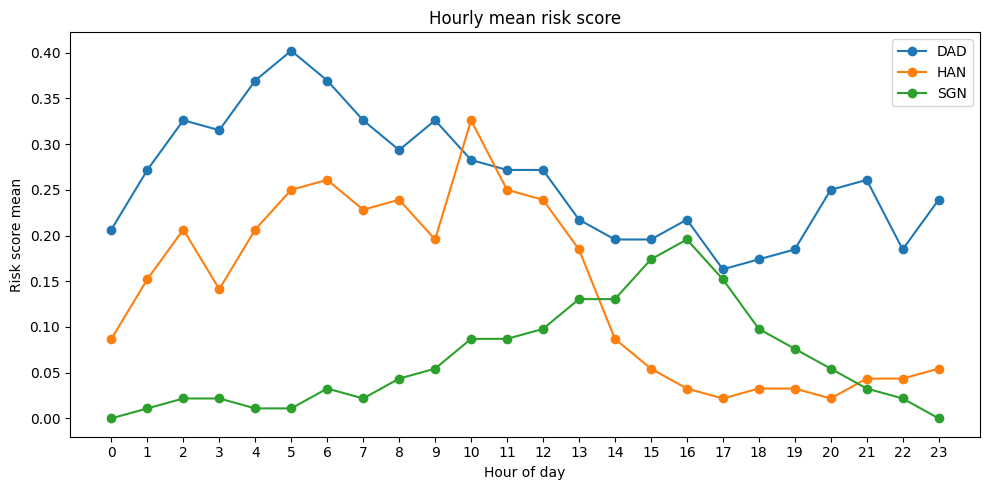

Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/02_hourly_precip_mean.png


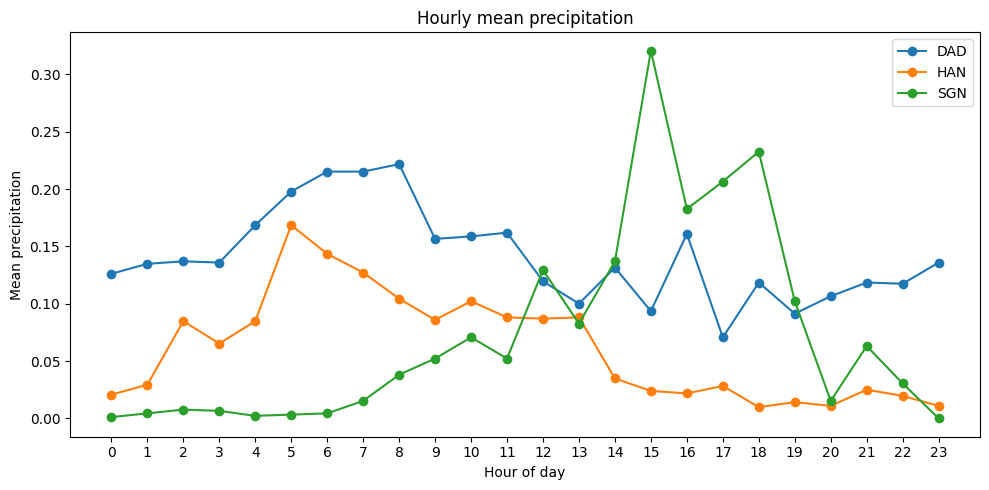

In [12]:
# =========================
# 2.3. Hourly pattern
# =========================

show_title("2.3. Hourly pattern")

hourly_agg = {
    "risk_mean": (risk_col, "mean"),
    "risk_positive_rate_pct": (risk_col, lambda x: (x > 0).mean() * 100),
}
if precip_col is not None:
    hourly_agg["precip_mean"] = (precip_col, "mean")
if COLS["is_rain"] is not None:
    hourly_agg["rain_rate_pct"] = (COLS["is_rain"], lambda x: x.mean() * 100)

hourly = df.groupby([airport_col, "_hour"]).agg(**hourly_agg).reset_index()
display_and_save(hourly, "02_hourly_pattern", max_rows=30)

# Risk hourly
plt.figure(figsize=(10, 5))
for airport, g in hourly.groupby(airport_col):
    plt.plot(g["_hour"], g["risk_mean"], marker="o", label=str(airport))
plt.title("Hourly mean risk score")
plt.xlabel("Hour of day")
plt.ylabel("Risk score mean")
plt.xticks(range(0, 24))
plt.legend()
save_fig("02_hourly_risk_mean.png")
plt.show()

# Precip hourly
if precip_col is not None:
    plt.figure(figsize=(10, 5))
    for airport, g in hourly.groupby(airport_col):
        plt.plot(g["_hour"], g["precip_mean"], marker="o", label=str(airport))
    plt.title("Hourly mean precipitation")
    plt.xlabel("Hour of day")
    plt.ylabel("Mean precipitation")
    plt.xticks(range(0, 24))
    plt.legend()
    save_fig("02_hourly_precip_mean.png")
    plt.show()

### Nhận xét:
- DAD: 
    + Chỉ số rủi ro đạt đỉnh với risk_mean cao nhất vào lúc 5h sáng (0.402). Đây là thời điểm cực kỳ nhạy cảm vì là lúc các chuyến bay đầu ngày chuẩn bị cất cánh. Nếu trễ ở khung giờ này, toàn bộ lịch trình trong ngày sẽ bị trễ dây chuyền (ripple effect).

    + Nghịch lý Lượng mưa vs Rủi ro: * Lượng mưa trung bình (precip_mean) cao nhất lại rơi vào lúc 8h sáng (0.221).

    + Tuy nhiên, tỷ lệ rủi ro (risk_positive_rate) lại cao nhất vào lúc 5h sáng (38%).

    + Rủi ro giảm xuống mức thấp nhất vào khoảng 17h - 18h (0.16 - 0.17).

Insight: Điều này cho thấy tại DAD, không chỉ có mưa mới gây rủi ro. Sương mù hoặc mây thấp vào rạng sáng (trước khi mặt trời lên) mới là yếu tố đẩy điểm rủi ro lên cao dù lượng mưa chưa phải là lớn nhất.

- HAN:
    + Áp lực tăng dần theo giấc ngủ rạng sáng
    + Dữ liệu HAN (dòng 24-29) cho thấy một xu hướng tăng vọt: Từ rủi ro 8.6% lúc 0h lên đến 25% lúc 5h sáng.

Đặc điểm: Tương tự DAD, khung giờ 5h sáng tại Nội Bài có precip_mean (0.168) tăng gấp 8 lần so với lúc 0h. Đây là dấu hiệu của mưa phùn hoặc sương mù đậm đặc kèm ẩm cao vào sáng sớm mùa Đông-Xuân miền Bắc.


- Tính chất Rain Rate
    + rain_rate_pct của DAD: Luôn duy trì ở mức 30% - 50% suốt từ 0h đến 12h trưa.

Nhận xét: Mưa ở DAD có tính chất kéo dài (persistent). Nó không phải là những cơn mưa rào nhanh rồi tạnh, mà là dạng mưa rỉ rả kéo dài nhiều giờ liền, gây ảnh hưởng liên tục đến tầm nhìn và điều kiện mặt đường băng.

- Kết luận và Ứng dụng vào Model dự báo:

    + Feature "Hour of Day": Bạn bắt buộc phải đưa biến giờ (0-23) vào model dưới dạng Cyclical Feature (sin/cos encoding). Khung giờ 4h-7h sáng cần được gán trọng số rủi ro cao hơn.

    + Mối quan hệ Delta (Biến thiên): Sự gia tăng rủi ro từ 3h sáng đến 5h sáng là một tín hiệu (signal) mạnh. Model nên học được rằng nếu rủi ro bắt đầu tăng từ lúc 3h, thì khả năng cao đỉnh điểm sẽ rơi vào lúc 5h-6h.

- Kết hợp với Flight Schedule
Rủi ro thực tế = (Weather Risk) x (Mật độ chuyến bay). 
* Vì đỉnh rủi ro thời tiết trùng với đỉnh bay sáng sớm (6h-8h), nên hậu quả trễ chuyến thực tế sẽ khốc liệt hơn nhiều so với chỉ nhìn vào con số thời tiết đơn thuần.

# Bước 3 — Correlation heatmap & feature relationship

Mục tiêu:
- Tìm feature tương quan mạnh nhất với `Weather_Delay_Risk_Score`.
- Ưu tiên kiểm tra `Precip_Cumsum_3H_Mm` vs risk.
- So sánh `Headwind_Kmh` và `Crosswind_Kmh`.
- Scatter `Visibility` vs `Humidity` theo sân bay.

### 3.1. Correlation with Weather_Delay_Risk_Score

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/03_corr_with_risk.csv


,corr_with_risk
Is_Thunderstorm_Risk,0.986488
Aviation_Operational_Risk_Score,0.921602
Runway_Wet_Risk,0.782550
Is_Rain,0.773176
Precip_Cumsum_3H_Mm,0.496037
Precip_Cumsum_1H_Mm,0.481983
precipitation,0.481983
Precip_Cumsum_6H_Mm,0.473796
Visibility_Capped_Flag,-0.423862
Visibility_SM,-0.410401


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/03_top_corr_with_risk.png


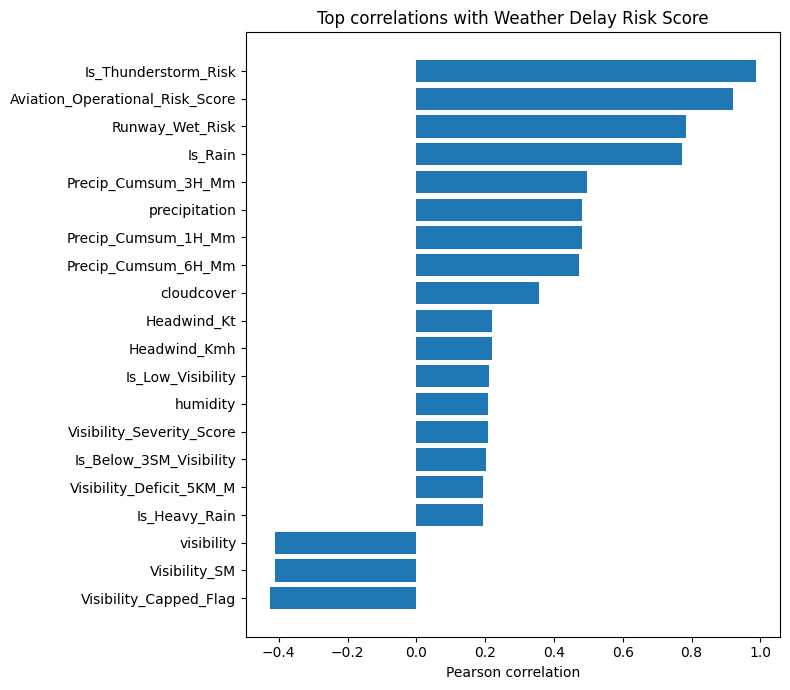

In [13]:
# =========================
# 3. Correlation analysis
# =========================

show_title("3.1. Correlation with Weather_Delay_Risk_Score")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_risk = (
    df[numeric_cols]
    .corr(numeric_only=True)[risk_col]
    .drop(labels=[risk_col], errors="ignore")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_risk")
)
display_and_save(corr_with_risk, "03_corr_with_risk", max_rows=30)

# Top correlation bar
top_corr = corr_with_risk.head(20).sort_values("corr_with_risk")
plt.figure(figsize=(8, 7))
plt.barh(top_corr.index, top_corr["corr_with_risk"])
plt.title("Top correlations with Weather Delay Risk Score")
plt.xlabel("Pearson correlation")
save_fig("03_top_corr_with_risk.png")
plt.show()

### 3.2. Correlation heatmap

Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/03_corr_heatmap_selected.png


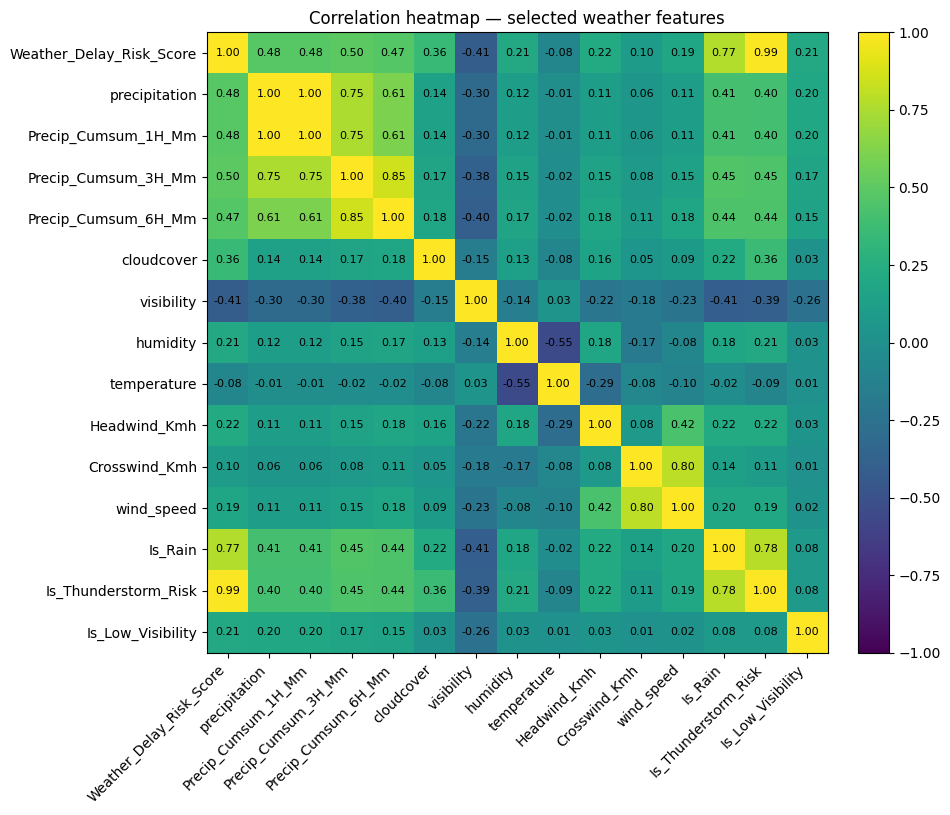

In [14]:
# =========================
# 3.2. Correlation heatmap
# =========================

show_title("3.2. Correlation heatmap")

# Chọn các feature liên quan nhất để heatmap dễ đọc
important_cols = [risk_col]
for key in [
    "precip", "precip_cumsum_1h", "precip_cumsum_3h", "precip_cumsum_6h",
    "cloudcover", "visibility", "humidity", "temperature",
    "headwind", "crosswind", "wind_speed",
    "is_rain", "is_thunderstorm", "is_low_visibility"
]:
    col = COLS.get(key)
    if col is not None and col in df.columns and col not in important_cols:
        important_cols.append(col)

important_cols = [c for c in important_cols if c in numeric_cols]
corr_matrix = df[important_cols].corr(numeric_only=True)

def plot_corr_heatmap(corr, title, filename):
    fig, ax = plt.subplots(figsize=(max(8, len(corr) * 0.65), max(6, len(corr) * 0.55)))
    im = ax.imshow(corr.values, vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(len(corr.columns)))
    ax.set_yticks(np.arange(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.index)
    ax.set_title(title)

    if len(corr) <= 18:
        for i in range(len(corr.index)):
            for j in range(len(corr.columns)):
                val = corr.iloc[i, j]
                if pd.notna(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
    save_fig(filename)
    plt.show()

plot_corr_heatmap(corr_matrix, "Correlation heatmap — selected weather features", "03_corr_heatmap_selected.png")
corr_matrix.to_csv(REPORT_DIR / "03_corr_heatmap_selected.csv")

### 3.3. Headwind vs Crosswind

,Weather_Delay_Risk_Score,Headwind_Kmh,Crosswind_Kmh,wind_speed
Weather_Delay_Risk_Score,1.000000,0.220591,0.103612,0.186629
Headwind_Kmh,0.220591,1.000000,0.078750,0.423410
Crosswind_Kmh,0.103612,0.078750,1.000000,0.804380
wind_speed,0.186629,0.423410,0.804380,1.000000


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/03_headwind_vs_risk.png


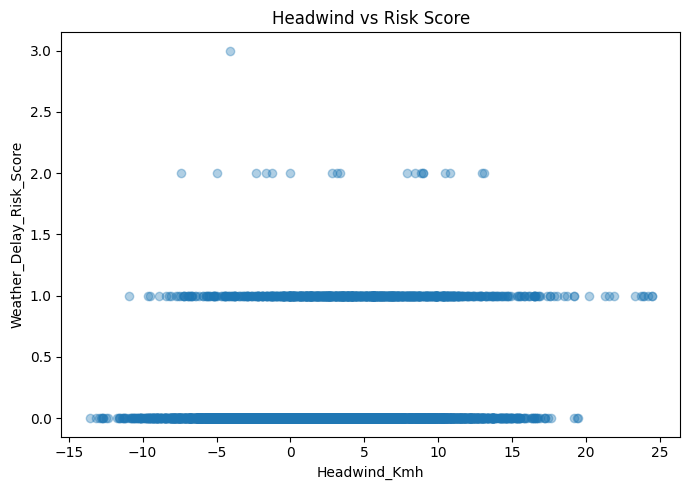

Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/03_crosswind_vs_risk.png


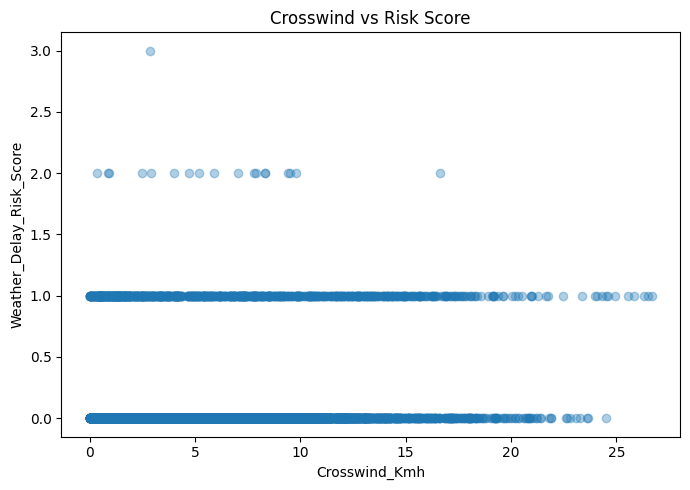

In [15]:
# =========================
# 3.3. Headwind vs Crosswind vs Risk
# =========================

show_title("3.3. Headwind vs Crosswind")

wind_compare_cols = [risk_col]
for key in ["headwind", "crosswind", "wind_speed"]:
    col = COLS.get(key)
    if col is not None:
        wind_compare_cols.append(col)

wind_compare_cols = [c for c in wind_compare_cols if c in numeric_cols]
if len(wind_compare_cols) > 1:
    wind_corr = df[wind_compare_cols].corr(numeric_only=True)
    display(wind_corr)
    wind_corr.to_csv(REPORT_DIR / "03_headwind_crosswind_corr.csv")

    if COLS["headwind"] is not None:
        plt.figure(figsize=(7, 5))
        plt.scatter(df[COLS["headwind"]], df[risk_col], alpha=0.35)
        plt.title("Headwind vs Risk Score")
        plt.xlabel(COLS["headwind"])
        plt.ylabel(risk_col)
        save_fig("03_headwind_vs_risk.png")
        plt.show()

    if COLS["crosswind"] is not None:
        plt.figure(figsize=(7, 5))
        plt.scatter(df[COLS["crosswind"]], df[risk_col], alpha=0.35)
        plt.title("Crosswind vs Risk Score")
        plt.xlabel(COLS["crosswind"])
        plt.ylabel(risk_col)
        save_fig("03_crosswind_vs_risk.png")
        plt.show()
else:
    print("Không đủ cột gió để phân tích Headwind/Crosswind.")

### Nhận xét:
- Gió ngược (Headwind) quan trọng hơn: Tương quan của Headwind với rủi ro trễ chuyến (0.22) cao gấp đôi so với Crosswind (0.10). Điều này phản ánh thực tế: gió ngược mạnh làm giảm tốc độ mặt đất, tăng thời gian giãn cách giữa các máy bay, gây ùn tắc dây chuyền.

- Crosswind tương quan cực cao với wind_speed (0.80)

### 3.4. Visibility vs Humidity by airport

Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/03_visibility_vs_humidity_by_airport.png


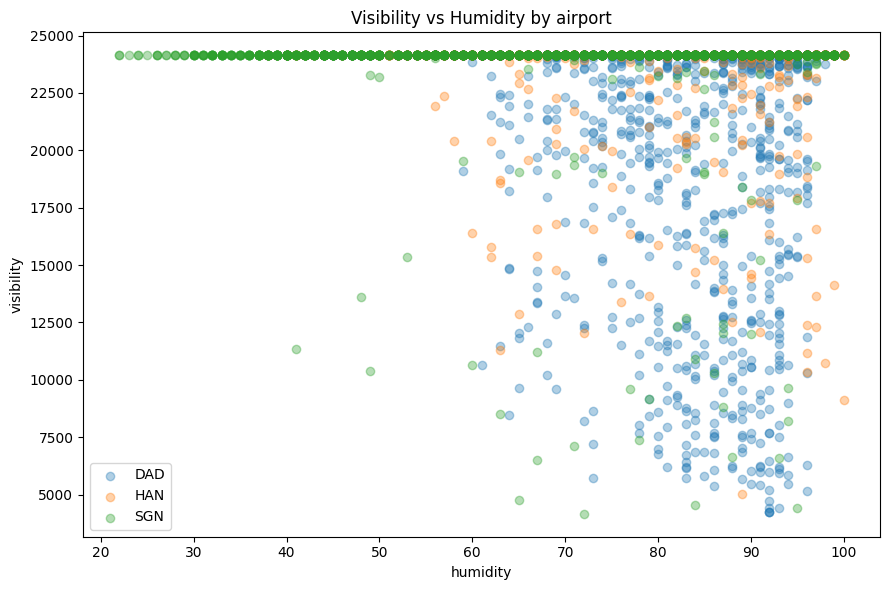

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/03_visibility_humidity_corr_by_airport.csv


,corr_visibility_humidity
Airport,
DAD,-0.091167
HAN,-0.077759
SGN,-0.068017


In [16]:
# =========================
# 3.4. Visibility vs Humidity by airport
# =========================

show_title("3.4. Visibility vs Humidity by airport")

if vis_col is not None and COLS["humidity"] is not None:
    hum_col = COLS["humidity"]
    sample_df = df[[airport_col, vis_col, hum_col, risk_col]].dropna()
    if len(sample_df) > 5000:
        sample_df = sample_df.sample(5000, random_state=42)

    plt.figure(figsize=(9, 6))
    for airport, g in sample_df.groupby(airport_col):
        plt.scatter(g[hum_col], g[vis_col], alpha=0.35, label=str(airport))
    plt.title("Visibility vs Humidity by airport")
    plt.xlabel(hum_col)
    plt.ylabel(vis_col)
    plt.legend()
    save_fig("03_visibility_vs_humidity_by_airport.png")
    plt.show()

    vis_hum_corr = (
        df.groupby(airport_col)
          .apply(lambda g: g[[vis_col, hum_col]].corr().iloc[0, 1])
          .to_frame("corr_visibility_humidity")
    )
    display_and_save(vis_hum_corr, "03_visibility_humidity_corr_by_airport")
else:
    print("Thiếu visibility hoặc humidity, bỏ qua scatter Visibility vs Humidity.")

### Nhận xét:

- Tương quan nghịch yếu bất ngờ: Hệ số tương quan dao động từ -0.068 đến -0.091 (gần như bằng 0). Theo lý thuyết, độ ẩm cao thường đi kèm sương mù làm giảm tầm nhìn, nhưng dữ liệu này không thể hiện rõ điều đó.

- Hệ số này thấp chủ yếu do biến visibility bị áp trần (capped) quá nặng (92-96% tại HAN/SGN). Khi tầm nhìn bị đứng yên ở mức 24,140m trong khi độ ẩm vẫn biến thiên liên tục, toán học không thể tìm thấy mối liên hệ tuyến tính.

# Bước 4 — Airport comparison

Mục tiêu:
- So sánh profile rủi ro giữa các sân bay.
- Tách risk do mưa/dông và risk do gió.
- Tạo radar chart 6 chiều: rain %, thunderstorm %, low vis %, crosswind, headwind, risk score.
- Gợi ý airport-specific thresholds bằng quantile.

### 4.1. Airport risk profile

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/04_airport_profile.csv


,hours,risk_mean,risk_positive_rate_pct,risk_ge2_rate_pct,risk_max,precip_mean,precip_sum,rain_rate_pct,thunderstorm_rate_pct,low_visibility_rate_pct,crosswind_mean,crosswind_max,headwind_mean,headwind_max
Airport,,,,,,,,,,,,,,
DAD,2208,0.263134,25.951087,0.362319,2,0.141395,312.2,40.353261,25.860507,0.407609,5.754950,20.78,1.889126,24.44
HAN,2208,0.141304,14.085145,0.045290,2,0.061594,136.0,17.255435,14.085145,0.000000,6.563601,26.68,5.285186,19.17
SGN,2208,0.065217,6.023551,0.452899,3,0.073324,161.9,10.824275,5.978261,0.226449,4.991875,18.80,-1.221644,8.95


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/04_risk_positive_rate_by_airport.png


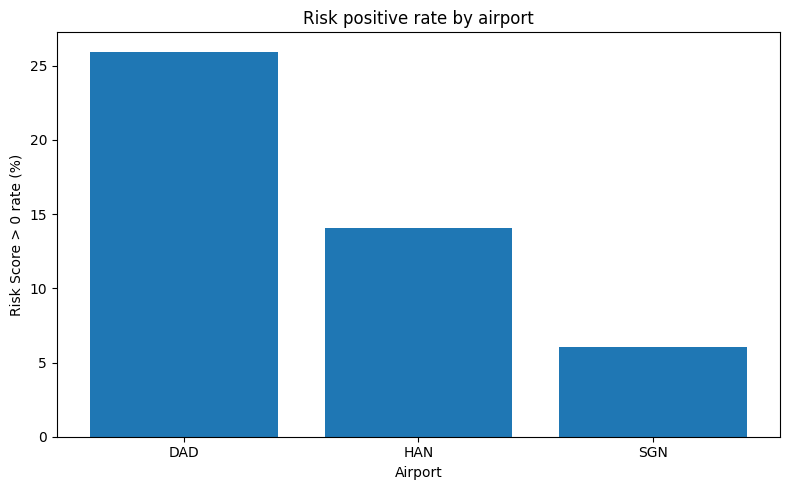

In [17]:
# =========================
# 4. Airport comparison
# =========================

show_title("4.1. Airport risk profile")

airport_agg = {
    "hours": (risk_col, "size"),
    "risk_mean": (risk_col, "mean"),
    "risk_positive_rate_pct": (risk_col, lambda x: (x > 0).mean() * 100),
    "risk_ge2_rate_pct": (risk_col, lambda x: (x >= 2).mean() * 100),
    "risk_max": (risk_col, "max"),
}
if precip_col is not None:
    airport_agg["precip_mean"] = (precip_col, "mean")
    airport_agg["precip_sum"] = (precip_col, "sum")
if COLS["is_rain"] is not None:
    airport_agg["rain_rate_pct"] = (COLS["is_rain"], lambda x: x.mean() * 100)
if COLS["is_thunderstorm"] is not None:
    airport_agg["thunderstorm_rate_pct"] = (COLS["is_thunderstorm"], lambda x: x.mean() * 100)
if COLS["is_low_visibility"] is not None:
    airport_agg["low_visibility_rate_pct"] = (COLS["is_low_visibility"], lambda x: x.mean() * 100)
if COLS["crosswind"] is not None:
    airport_agg["crosswind_mean"] = (COLS["crosswind"], "mean")
    airport_agg["crosswind_max"] = (COLS["crosswind"], "max")
if COLS["headwind"] is not None:
    airport_agg["headwind_mean"] = (COLS["headwind"], "mean")
    airport_agg["headwind_max"] = (COLS["headwind"], "max")

airport_profile = df.groupby(airport_col).agg(**airport_agg).sort_values("risk_mean", ascending=False)
display_and_save(airport_profile, "04_airport_profile", max_rows=20)

# Bar risk positive rate
plt.figure(figsize=(8, 5))
plt.bar(airport_profile.index.astype(str), airport_profile["risk_positive_rate_pct"])
plt.title("Risk positive rate by airport")
plt.xlabel("Airport")
plt.ylabel("Risk Score > 0 rate (%)")
save_fig("04_risk_positive_rate_by_airport.png")
plt.show()

### Nhận xét:

- Đà Nẵng (DAD): 

    + Tần suất rủi ro cực cao: DAD đứng đầu mọi chỉ số về mức độ phổ biến với risk_positive_rate lên tới 25.95% và tỷ lệ mưa gần 40.4%. Điều này có nghĩa là cứ 4 giờ bay thì có 1 giờ đối mặt với rủi ro thời tiết.

    + Đặc trưng rủi ro: Rủi ro tại DAD mang tính hệ thống và kéo dài (diện rộng). Lượng mưa tổng cộng (precip_sum) cao gấp đôi HAN và SGN cộng lại.

Tầm nhìn: Đây cũng là nơi duy nhất có vấn đề thực sự với tầm nhìn thấp (low_visibility_rate = 0.4%), trong khi HAN báo cáo là 0% (do lỗi sensor đã audit).

- Nội Bài (HAN): Đặc trưng tiềm ẩn từ Gió ngang

    + Dù lượng mưa thấp nhất, nhưng HAN lại sở hữu crosswind_max cao nhất (26.68 km/h). Đây là yếu tố cực kỳ quan trọng vì Nội Bài thường xuyên chịu ảnh hưởng của gió mùa Đông Bắc thổi lệch tâm đường băng.

    + Sự mâu thuẫn dữ liệu: low_visibility_rate bằng 0.0% là một điểm "phi thực tế" đối với mùa Đông Bắc tại miền Bắc.

Nhận xét: Model sẽ bị "mù" về sương mù tại HAN nếu chỉ dựa vào cột này. Bạn cần sử dụng humidity và crosswind làm biến thay thế chính cho rủi ro tại đây.

- Tân Sơn Nhất (SGN): 

    + Nghịch lý Risk Score: SGN có risk_mean thấp nhất (0.06) nhưng lại có risk_max cao nhất (Score = 3).

    + Rủi ro cực đoan: Tỷ lệ rủi ro nặng (risk_ge2_rate) của SGN là 0.45%, cao hơn cả DAD và HAN.

Insight: Thời tiết SGN trong giai đoạn này (mùa khô) rất ổn định, nhưng một khi có biến cố (thường là dông nhiệt bất ngờ), nó sẽ đẩy mức độ rủi ro lên kịch trần, gây tắc nghẽn nghiêm trọng hơn cả mưa dầm ở miền Trung.

- Phân tích Gió ngược (Headwind)

    + HAN & DAD: Có headwind_mean dương (5.2 - 1.8), hỗ trợ tốt cho việc cất/hạ cánh ổn định.

    + SGN: Có headwind_mean âm (-1.22), nghĩa là sân bay này thường xuyên phải đối mặt với Tailwind (gió xuôi).

Rủi ro: Gió xuôi làm tăng quãng đường chạy đà và hạ cánh, dễ dẫn đến việc tàu bay phải chờ đổi đầu đường băng (runway change), gây trễ chuyến hàng loạt.

### 4.2. Radar chart airport profile

Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/04_airport_radar_profile.png


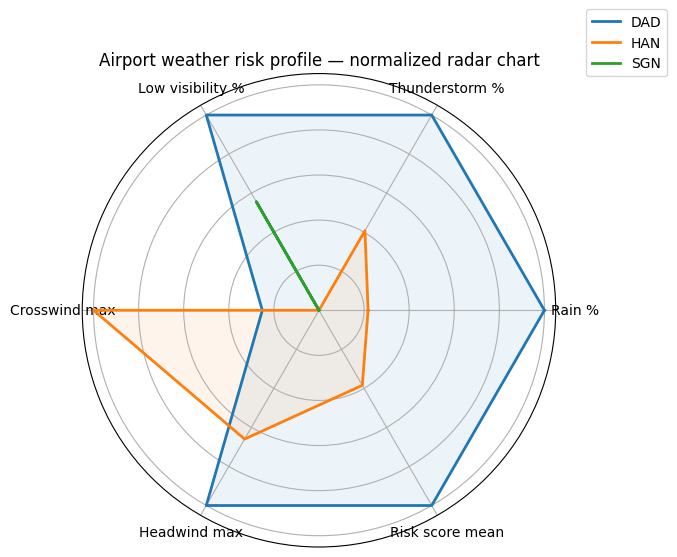

In [18]:
# =========================
# 4.2. Radar chart
# =========================

show_title("4.2. Radar chart airport profile")

radar_metrics = []
metric_name_map = {}

candidate_metrics = {
    "rain_rate_pct": "Rain %",
    "thunderstorm_rate_pct": "Thunderstorm %",
    "low_visibility_rate_pct": "Low visibility %",
    "crosswind_max": "Crosswind max",
    "headwind_max": "Headwind max",
    "risk_mean": "Risk score mean",
}

for col, label in candidate_metrics.items():
    if col in airport_profile.columns:
        radar_metrics.append(col)
        metric_name_map[col] = label

if len(radar_metrics) >= 3:
    radar = airport_profile[radar_metrics].copy()

    # Normalize 0-1 để vẽ radar
    radar_norm = radar.copy()
    for col in radar_norm.columns:
        min_v, max_v = radar_norm[col].min(), radar_norm[col].max()
        if max_v > min_v:
            radar_norm[col] = (radar_norm[col] - min_v) / (max_v - min_v)
        else:
            radar_norm[col] = 0

    labels = [metric_name_map[c] for c in radar_metrics]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, polar=True)
    for airport, row in radar_norm.iterrows():
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=str(airport))
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels([])
    ax.set_title("Airport weather risk profile — normalized radar chart")
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.15))
    save_fig("04_airport_radar_profile.png")
    plt.show()

    radar.to_csv(REPORT_DIR / "04_airport_radar_raw_metrics.csv")
    radar_norm.to_csv(REPORT_DIR / "04_airport_radar_normalized.csv")
else:
    print("Không đủ metric để vẽ radar chart.")

In [19]:
# =========================
# 4.3. Airport-specific thresholds
# =========================

show_title("4.3. Airport-specific thresholds")

threshold_features = []
for key in ["precip", "crosswind", "headwind", "wind_speed"]:
    col = COLS.get(key)
    if col is not None and col in df.columns:
        threshold_features.append(col)

threshold_rows = []
for airport, g in df.groupby(airport_col):
    for col in threshold_features:
        threshold_rows.append({
            "airport": airport,
            "feature": col,
            "p50": g[col].quantile(0.50),
            "p75": g[col].quantile(0.75),
            "p90": g[col].quantile(0.90),
            "p95": g[col].quantile(0.95),
            "p99": g[col].quantile(0.99),
            "max": g[col].max(),
        })

airport_thresholds = pd.DataFrame(threshold_rows)
display_and_save(airport_thresholds, "04_airport_specific_threshold_candidates", max_rows=50)

### 4.3. Airport-specific thresholds

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/04_airport_specific_threshold_candidates.csv


,airport,feature,p50,p75,p90,p95,p99,max
0,DAD,precipitation,0.00,0.1000,0.400,0.6000,1.6000,6.00
1,DAD,Crosswind_Kmh,4.37,8.7925,12.700,14.3865,17.9600,20.78
2,DAD,Headwind_Kmh,1.23,5.6225,9.900,12.4755,17.2372,24.44
3,DAD,wind_speed,7.90,11.8000,15.200,17.0650,21.0930,25.40
4,HAN,precipitation,0.00,0.0000,0.200,0.3000,1.0930,6.60
5,HAN,Crosswind_Kmh,5.30,9.1500,14.130,17.0960,21.8923,26.68
6,HAN,Headwind_Kmh,5.27,8.7300,11.300,12.8565,15.3872,19.17
7,HAN,wind_speed,9.20,12.9000,16.300,18.1650,22.8930,27.50
8,SGN,precipitation,0.00,0.0000,0.100,0.2000,1.6000,13.90
9,SGN,Crosswind_Kmh,4.40,7.2075,9.950,11.6830,14.0565,18.80


### Nhận xét:
- Precipitation (Lượng mưa): 

    + DAD: Mưa dầm (nói trên)
    
    + SGN: Mưa cực đoan: Có đặc trưng "mưa bóng mây" nhưng cực mạnh. Nhìn vào khoảng cách giữa P99 ($1.6mm$) và Max ($13.9mm$), ta thấy những trận mưa cực đoan tại SGN có cường độ gấp gần 9 lần mức 99% còn lại.

- Crosswind (Gió ngang) - HAN 

- Wind speed: 

    + HAN có tốc độ gió duy trì (P50 = 9.2 km/h) cao gấp 1.6 lần SGN (5.7 km/h).Dữ liệu cho thấy SGN là sân bay "lặng gió" nhất nhưng lại có rủi ro dông nhiệt

- Headwind (Gió ngược)

# Bước 5 — Event-based EDA

Mục tiêu:
- Tập trung vào extreme events: `Weather_Delay_Risk_Score >= 2`.
- Cluster các giờ rủi ro liên tiếp theo sân bay.
- Kiểm tra imbalance của target.

### 5.1. Target distribution and imbalance

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/05_target_distribution.csv


,count,rate_pct
Weather_Delay_Risk_Score,,
0,5607,84.646739
1,998,15.066425
2,18,0.271739
3,1,0.015097


Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/05_imbalance_summary.csv


,target_definition,positive_count,negative_count,positive_rate_pct,negative_to_positive_ratio
0,Risk > 0,1017,5607,15.353261,5.513274
1,Risk >= 2,19,6605,0.286836,347.631579


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/05_risk_score_distribution.png


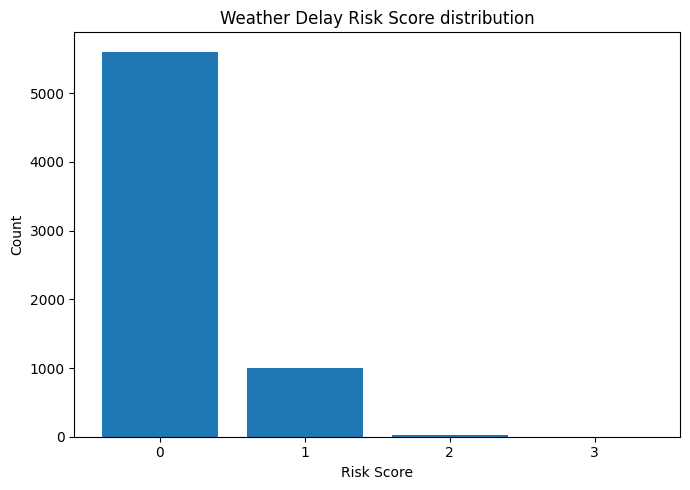

In [20]:
# =========================
# 5. Event-based EDA and imbalance
# =========================

show_title("5.1. Target distribution and imbalance")

target_dist = df[risk_col].value_counts(dropna=False).sort_index().to_frame("count")
target_dist["rate_pct"] = target_dist["count"] / len(df) * 100
display_and_save(target_dist, "05_target_distribution")

risk_positive = (df[risk_col] > 0).sum()
risk_ge2 = (df[risk_col] >= 2).sum()
imbalance_summary = pd.DataFrame({
    "target_definition": ["Risk > 0", "Risk >= 2"],
    "positive_count": [risk_positive, risk_ge2],
    "negative_count": [len(df) - risk_positive, len(df) - risk_ge2],
    "positive_rate_pct": [risk_positive / len(df) * 100, risk_ge2 / len(df) * 100],
    "negative_to_positive_ratio": [
        (len(df) - risk_positive) / risk_positive if risk_positive > 0 else np.inf,
        (len(df) - risk_ge2) / risk_ge2 if risk_ge2 > 0 else np.inf,
    ],
})
display_and_save(imbalance_summary, "05_imbalance_summary")

plt.figure(figsize=(7, 5))
plt.bar(target_dist.index.astype(str), target_dist["count"])
plt.title("Weather Delay Risk Score distribution")
plt.xlabel("Risk Score")
plt.ylabel("Count")
save_fig("05_risk_score_distribution.png")
plt.show()

### Nhận xét:

- Phân phối Risk Score: "Đuôi dài" cực đoan (Long-tail)

    + Thống trị của Score 0 (84.6%): Đa số thời gian thời tiết ở trạng thái an toàn. Đây là đặc điểm tự nhiên của dữ liệu hàng không (an toàn là ưu tiên số 1).

    + Sự quý giá của Score 3 (chỉ có 1 dòng): Chỉ chiếm 0.015%. Đây là "điểm gãy" vận hành hiếm hoi (trận mưa 13.9mm tại SGN).

Nhận xét: Nếu dùng Model hồi quy (Regression), sai số tại Score 3 sẽ cực lớn vì dữ liệu quá ít.

- Imbalance ratio: 

    + Bài toán Risk > 0 (Tỷ lệ 1:5.5): 15.3% dữ liệu có rủi ro. Mức độ lệch này là vừa phải. Các thuật toán ML thông thường có thể xử lý tốt với một chút điều chỉnh trọng số (class weight).

    + Bài toán Risk >= 2 (Tỷ lệ 1:347): Đây là rủi ro nghiêm trọng thực sự, nhưng chỉ chiếm 0.28%.

Nhận xét: Với tỷ lệ 1 chọi 347, nếu model dự đoán "Không có rủi ro nặng" cho 100% dữ liệu, nó vẫn đạt độ chính xác (Accuracy) tới 99.7%. Nhưng model đó hoàn toàn vô dụng vì nó bỏ lỡ tất cả các ca trễ chuyến nặng.

Lưu ý: Lựa chọn Metric đánh giá: KHÔNG dùng Accuracy; dùng F1-Score, Precision-Recall Curve, hoặc AUC-PR để đánh giá hiệu suất trên tập rủi ro (Minority class).

### 5.2. Extreme events: Risk Score >= 2

Number of hours with Risk Score >= 2: 19
Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/05_extreme_event_clusters.csv


,Airport,_cluster_id,start_time,end_time,duration_hours,risk_max,risk_mean,precip_sum,precip_max,crosswind_max,headwind_max,visibility_min
10,SGN,SGN_C4,2025-12-25 18:00:00,2025-12-25 18:00:00,1,3,3.0,13.9,13.9,2.87,-4.10,4400.0
4,DAD,DAD_C5,2026-03-10 05:00:00,2026-03-10 07:00:00,3,2,2.0,4.2,1.9,9.81,10.82,4380.0
2,DAD,DAD_C3,2026-03-09 23:00:00,2026-03-10 00:00:00,2,2,2.0,4.0,2.2,9.52,13.11,3960.0
12,SGN,SGN_C6,2026-01-06 15:00:00,2026-01-06 15:00:00,1,2,2.0,12.5,12.5,3.99,8.95,9180.0
15,SGN,SGN_C9,2026-02-27 12:00:00,2026-02-27 12:00:00,1,2,2.0,7.0,7.0,8.34,3.37,23620.0
5,HAN,HAN_C1,2026-01-01 05:00:00,2026-01-01 05:00:00,1,2,2.0,6.6,6.6,2.90,8.94,24140.0
13,SGN,SGN_C7,2026-01-06 17:00:00,2026-01-06 17:00:00,1,2,2.0,6.4,6.4,4.74,7.89,23340.0
8,SGN,SGN_C2,2025-12-25 14:00:00,2025-12-25 14:00:00,1,2,2.0,6.1,6.1,16.63,-7.40,24140.0
0,DAD,DAD_C1,2026-03-03 16:00:00,2026-03-03 16:00:00,1,2,2.0,6.0,6.0,0.86,-1.23,21300.0
7,SGN,SGN_C10,2026-02-27 15:00:00,2026-02-27 15:00:00,1,2,2.0,5.4,5.4,2.50,-0.04,24140.0


Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/05_daily_extreme_events.csv


,Airport,_date,hours_ge2,risk_max
3,DAD,2026-03-10,5,2
6,SGN,2025-12-25,3,3
8,SGN,2026-01-06,2,2
10,SGN,2026-02-27,2,2
0,DAD,2026-03-03,1,2
1,DAD,2026-03-04,1,2
2,DAD,2026-03-09,1,2
4,HAN,2026-01-01,1,2
5,SGN,2025-12-24,1,2
7,SGN,2025-12-27,1,2


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/05_risk_timeline_scatter.png


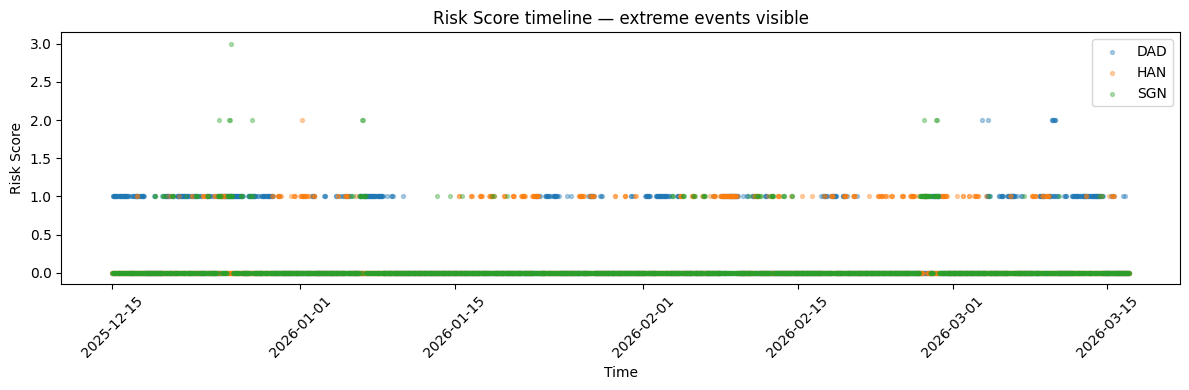

In [21]:
# =========================
# 5.2. Extreme event clusters
# =========================

show_title("5.2. Extreme events: Risk Score >= 2")

events = df[df[risk_col] >= 2].copy()
print("Number of hours with Risk Score >= 2:", len(events))

if len(events) > 0:
    sort_cols = [airport_col, dt_col]
    events = events.sort_values(sort_cols).reset_index(drop=True)
    events["_gap_h"] = events.groupby(airport_col)[dt_col].diff().dt.total_seconds() / 3600
    events["_new_cluster"] = events["_gap_h"].isna() | (events["_gap_h"] > 1.5)
    events["_cluster_no"] = events.groupby(airport_col)["_new_cluster"].cumsum()
    events["_cluster_id"] = events[airport_col].astype(str) + "_C" + events["_cluster_no"].astype(str)

    cluster_agg = {
        "start_time": (dt_col, "min"),
        "end_time": (dt_col, "max"),
        "duration_hours": (dt_col, "size"),
        "risk_max": (risk_col, "max"),
        "risk_mean": (risk_col, "mean"),
    }
    if precip_col is not None:
        cluster_agg["precip_sum"] = (precip_col, "sum")
        cluster_agg["precip_max"] = (precip_col, "max")
    if COLS["crosswind"] is not None:
        cluster_agg["crosswind_max"] = (COLS["crosswind"], "max")
    if COLS["headwind"] is not None:
        cluster_agg["headwind_max"] = (COLS["headwind"], "max")
    if vis_col is not None:
        cluster_agg["visibility_min"] = (vis_col, "min")

    sort_key = "precip_sum" if precip_col is not None else "risk_mean"
    event_clusters = (
        events.groupby([airport_col, "_cluster_id"])
              .agg(**cluster_agg)
              .reset_index()
              .sort_values(["risk_max", "duration_hours", sort_key], ascending=False)
    )
    display_and_save(event_clusters, "05_extreme_event_clusters", max_rows=50)

    # Daily high risk summary
    daily_events = (
        events.groupby([airport_col, "_date"])
              .agg(hours_ge2=(risk_col, "size"), risk_max=(risk_col, "max"))
              .reset_index()
              .sort_values(["hours_ge2", "risk_max"], ascending=False)
    )
    display_and_save(daily_events, "05_daily_extreme_events", max_rows=50)

    # Timeline plot
    plt.figure(figsize=(12, 4))
    for airport, g in df.groupby(airport_col):
        plt.scatter(g[dt_col], g[risk_col], s=8, alpha=0.35, label=str(airport))
    plt.title("Risk Score timeline — extreme events visible")
    plt.xlabel("Time")
    plt.ylabel("Risk Score")
    plt.legend()
    plt.xticks(rotation=45)
    save_fig("05_risk_timeline_scatter.png")
    plt.show()
else:
    print("Không có event Risk Score >= 2.")

### Nhận xét:

- SGN (Tân Sơn Nhất):

    + Các cụm rủi ro tại SGN đa số chỉ kéo dài 1 giờ (duration_hours = 1).

    + Cường độ cực lớn: Sự kiện SGN_C4 (25/12) có lượng mưa 13.9mm/h và SGN_C6 là 12.5mm/h.

    + Gió xuôi (Tailwind): Hầu hết các sự kiện tại SGN có headwind_max mang giá trị âm (ví dụ: -4.1, -7.4, -5.0).

=> Kết luận: Rủi ro tại SGN là các trận dông ngắn, mưa rất to và gió đổi chiều gây bất lợi cho hạ cánh.

- DAD (Đà Nẵng):

    + Các cụm rủi ro thường kéo dài từ 2-3 giờ liên tục.

    + Sự kiện DAD_C3 và DAD_C2 có tầm nhìn giảm xuống rất thấp (3,960m và 4,940m).

=> Kết luận: DAD đối mặt với rủi ro mang tính bền bỉ, kết hợp giữa mưa dầm và mù làm giảm năng suất sân bay trong thời gian dài.

- HAN (Nội Bài):

    + Chỉ xuất hiện 1 cụm rủi ro đáng kể (HAN_C1) vào sáng sớm ngày đầu năm mới (1/1).

=> Kết luận: Nội Bài trong tập dữ liệu này ít có các đỉnh rủi ro đột ngột về mưa so với hai sân bay miền Trung và miền Nam.

- OutlierS: Sự kiện SGN_C4 (18h ngày 25/12/2025): Đây là điểm duy nhất đạt Risk Score 3. 

    + Mưa cực lớn (13.9mm), gió xuôi mạnh (-4.1 km/h), tầm nhìn giảm xuống 4,400m.

    + Đây chắc chắn là một trận dông quét qua vào đúng khung giờ cao điểm tối, khả năng cao gây ra tình trạng bay chờ (holding) hoặc chuyển hướng (divert) hàng loạt.

- Tính chất "Bắc cầu" (Chain Events)
    + Ngày 10/03/2026 tại DAD có tới 5 giờ rủi ro nặng (hours_ge2 = 5).

    + Trong bảng cụm, ta thấy DAD_C5 kéo dài 3 tiếng và DAD_C4 kéo dài 1 tiếng.

Insight: Đây là một đợt thời tiết xấu kéo dài cả buổi sáng. Trong hàng không, 5 giờ rủi ro liên tục tại một sân bay như DAD sẽ tạo ra hiệu ứng "nghẽn cổ chai" cho toàn mạng bay nội địa Việt Nam.

# Bước 6 — Visibility threshold analysis

Mục tiêu:
- Không dùng giá trị visibility tuyệt đối nếu bị capped nặng.
- Phân tích theo threshold: dưới 10,000m, 5,000m, 3,000m.
- Kiểm tra low visibility xảy ra vào ban đêm/sáng sớm hay ban ngày.

### 6. Visibility threshold analysis

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/06_visibility_threshold_summary.csv


,hours,below_10000m_hours,below_10000m_rate_pct,below_5000m_hours,below_5000m_rate_pct,below_3000m_hours,below_3000m_rate_pct
airport,,,,,,,
DAD,2208,134,6.068841,9,0.407609,0,0.0
HAN,2208,3,0.135870,0,0.000000,0,0.0
SGN,2208,19,0.860507,5,0.226449,0,0.0


_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Airport,,,,,,,,,,,,,,,,,,,,,,,,
DAD,8.695652,7.608696,5.434783,5.434783,7.608696,9.782609,9.782609,5.434783,6.521739,5.434783,6.521739,6.521739,4.347826,3.26087,6.521739,4.347826,3.26087,4.347826,5.434783,4.347826,5.434783,7.608696,5.434783,6.521739
HAN,0.000000,2.173913,0.000000,0.000000,0.000000,1.086957,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
SGN,0.000000,0.000000,1.086957,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.086957,3.260870,3.26087,1.086957,3.260870,4.347826,2.173913,1.086957,0.000000,0.000000


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/06_visibility_below_10000m_heatmap.png


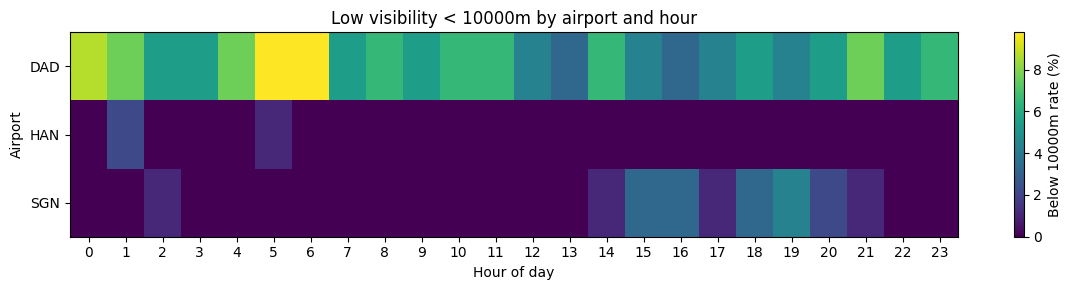

_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Airport,,,,,,,,,,,,,,,,,,,,,,,,
DAD,1.086957,0.0,1.086957,1.086957,0.0,2.173913,1.086957,1.086957,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,1.086957,0.0,0.0,0.0,1.086957
HAN,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000
SGN,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.26087,0.0,2.173913,0.000000,0.0,0.0,0.0,0.000000


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/06_visibility_below_5000m_heatmap.png


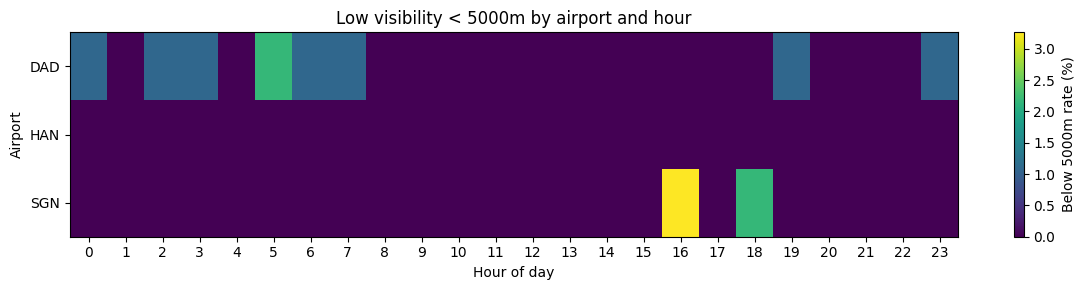

_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Airport,,,,,,,,,,,,,,,,,,,,,,,,
DAD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HAN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SGN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/06_visibility_below_3000m_heatmap.png


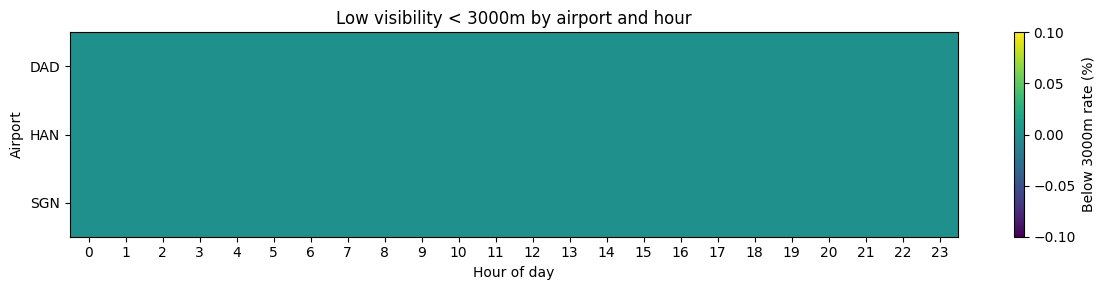

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/06_low_visibility_by_daypart.csv


,Airport,_daypart,lowvis_hours,total_hours,lowvis_rate,threshold_m,lowvis_rate_pct
0,DAD,afternoon_12_17,24,552,0.043478,10000,4.347826
1,DAD,evening_18_23,32,552,0.057971,10000,5.797101
2,DAD,morning_06_11,37,552,0.067029,10000,6.702899
3,DAD,night_00_05,41,552,0.074275,10000,7.427536
4,HAN,afternoon_12_17,0,552,0.000000,10000,0.000000
5,HAN,evening_18_23,0,552,0.000000,10000,0.000000
6,HAN,morning_06_11,0,552,0.000000,10000,0.000000
7,HAN,night_00_05,3,552,0.005435,10000,0.543478
8,SGN,afternoon_12_17,8,552,0.014493,10000,1.449275
9,SGN,evening_18_23,10,552,0.018116,10000,1.811594


In [22]:
# =========================
# 6. Visibility threshold analysis
# =========================

show_title("6. Visibility threshold analysis")

if vis_col is not None:
    thresholds = [10000, 5000, 3000]

    for th in thresholds:
        df[f"Visibility_Below_{th}m"] = (df[vis_col] < th).astype(int)

    vis_threshold_rows = []
    for airport, g in df.groupby(airport_col):
        row = {"airport": airport, "hours": len(g)}
        for th in thresholds:
            col = f"Visibility_Below_{th}m"
            row[f"below_{th}m_hours"] = int(g[col].sum())
            row[f"below_{th}m_rate_pct"] = g[col].mean() * 100
        vis_threshold_rows.append(row)

    vis_threshold_summary = pd.DataFrame(vis_threshold_rows).set_index("airport")
    display_and_save(vis_threshold_summary, "06_visibility_threshold_summary")

    # By airport and hour heatmap table
    for th in thresholds:
        col = f"Visibility_Below_{th}m"
        hour_table = (
            df.groupby([airport_col, "_hour"])[col]
              .mean()
              .mul(100)
              .reset_index()
              .pivot(index=airport_col, columns="_hour", values=col)
              .fillna(0)
        )
        display(hour_table)
        hour_table.to_csv(REPORT_DIR / f"06_visibility_below_{th}m_by_airport_hour.csv")

        plt.figure(figsize=(12, max(3, 0.6 * len(hour_table))))
        plt.imshow(hour_table.values, aspect="auto")
        plt.colorbar(label=f"Below {th}m rate (%)")
        plt.yticks(range(len(hour_table.index)), hour_table.index)
        plt.xticks(range(len(hour_table.columns)), hour_table.columns)
        plt.title(f"Low visibility < {th}m by airport and hour")
        plt.xlabel("Hour of day")
        plt.ylabel("Airport")
        save_fig(f"06_visibility_below_{th}m_heatmap.png")
        plt.show()

    # Daypart analysis
    def daypart(hour):
        if 0 <= hour <= 5:
            return "night_00_05"
        if 6 <= hour <= 11:
            return "morning_06_11"
        if 12 <= hour <= 17:
            return "afternoon_12_17"
        return "evening_18_23"

    df["_daypart"] = df["_hour"].apply(daypart)
    lowvis_daypart = []
    for th in thresholds:
        col = f"Visibility_Below_{th}m"
        tmp = (
            df.groupby([airport_col, "_daypart"])[col]
              .agg(["sum", "count", "mean"])
              .rename(columns={"sum": "lowvis_hours", "count": "total_hours", "mean": "lowvis_rate"})
              .reset_index()
        )
        tmp["threshold_m"] = th
        tmp["lowvis_rate_pct"] = tmp["lowvis_rate"] * 100
        lowvis_daypart.append(tmp)

    lowvis_daypart = pd.concat(lowvis_daypart, ignore_index=True)
    display_and_save(lowvis_daypart, "06_low_visibility_by_daypart", max_rows=50)
else:
    print("Không có cột visibility, bỏ qua Bước 6.")

### Nhận xét:
- Rủi ro Visibility

    + DAD (Đà Nẵng) - Rủi ro hệ thống: Là sân bay chịu ảnh hưởng của tầm nhìn thấp nặng nề nhất với tỷ lệ tổng thể là 6.07%. Đáng chú ý, DAD có rủi ro dàn trải suốt cả ngày, đặc biệt là vào ban đêm và sáng sớm với tỷ lệ lần lượt là 7.43% và 6.70%. Điều này cho thấy sương mù hoặc mưa phùn tại miền Trung có tính chất bền bỉ.
    
    + SGN (Tân Sơn Nhất) - Rủi ro cục bộ: Tỷ lệ tầm nhìn thấp tổng thể chỉ 0.86%, nhưng lại có tỷ lệ "mù nặng" ($< 5000m$) tương đối cao so với chính nó (0.22%). Khác với DAD, rủi ro tại SGN tập trung vào buổi chiều (1.45%) và tối (1.81%).
    
    + HAN (Nội Bài) - Vùng trắng dữ liệu: Tỷ lệ gần như bằng 0 (chỉ 0.13%). Như đã phân tích ở các phần trước, đây là dấu hiệu của việc làm sạch dữ liệu hoặc cảm biến bị giới hạn (Capping), không phản ánh đúng thực tế sương mù miền Bắc.

- Khung giờ:

    + Khung giờ Sáng sớm (Night/Morning): DAD. Tầm nhìn dưới $10,000m$ đạt đỉnh vào lúc 5h-6h sáng (9.78%). Điều này gây áp lực cực lớn lên các chuyến bay cất cánh sớm (first waves), dễ dẫn đến trễ chuyến dây chuyền cho cả ngày.

    + Khung giờ Chiều tối (Afternoon/Evening): Là thời điểm nhạy cảm của SGN. Rủi ro tập trung từ 15h đến 20h. Đây là khung giờ vàng của các chuyến bay trục HAN-SGN, việc tầm nhìn giảm đột ngột do dông sẽ khiến năng suất tiếp nhận tàu bay giảm mạnh, gây bay chờ (holding) hàng loạt.

- Ngưỡng tầm nhìn: 
Ngưỡng 5000m: Đây là ngưỡng bắt đầu ảnh hưởng đến tiêu chuẩn hạ cánh của nhiều loại tàu bay và trình độ phi công.
    
    + DAD có 9 giờ rơi vào ngưỡng này trong giai đoạn ban đêm.

    + SGN có các sự kiện mù nặng tập trung vào buổi chiều.

Ngưỡng 3000m: Rất may mắn là trong tập dữ liệu hiện tại, chưa ghi nhận giờ nào tầm nhìn rơi xuống dưới 3000m ở cả 3 sân bay. Điều này có nghĩa là các sự kiện "đóng cửa sân bay hoàn toàn" do tầm nhìn chưa xuất hiện, rủi ro hiện tại chủ yếu là làm giảm tốc độ khai thác.

# NEW WEATHER COLUMNS AFTER RE-CRAWL -- EDA block

This block is intentionally placed here so it is easy to find. It analyzes the new weather fields added by the latest crawl and the aviation features created in `weather_preprocessing.py`.

Covered fields: `dew_point_2m`, `weather_code`, `cape`, `lifted_index`, `cloud_cover_low`, `Dew_Point_Spread_C`, `Is_Radiation_Fog_Risk`, `Is_Low_Ceiling_Risk`, `Is_Severe_Convection_Risk`, `Tailwind_Default_Runway_Kt`, `Forced_Runway_Swap_Risk`.


In [23]:
# =========================
# 6.3. New weather field coverage and rates
# =========================

show_title("6.3. New weather field coverage and rates")

risk_oper_col = "Aviation_Operational_Risk_Score" if "Aviation_Operational_Risk_Score" in df.columns else risk_col

new_weather_candidates = {
    "dew_point_2m": ["dew_point_2m", "dewpoint", "dew_point"],
    "weather_code": ["weather_code", "wmo_code"],
    "cape": ["cape"],
    "lifted_index": ["lifted_index", "liftedindex"],
    "cloud_cover_low": ["cloud_cover_low", "low_cloud_cover"],
    "Dew_Point_Spread_C": ["Dew_Point_Spread_C", "dew_point_spread"],
    "Is_Radiation_Fog_Risk": ["Is_Radiation_Fog_Risk", "radiation_fog_risk"],
    "Is_Low_Ceiling_Risk": ["Is_Low_Ceiling_Risk", "low_ceiling"],
    "Is_Severe_Convection_Risk": ["Is_Severe_Convection_Risk", "severe_convection"],
    "Convective_Severity_Score": ["Convective_Severity_Score", "convective_severity"],
    "Gust_Variation_Kt": ["Gust_Variation_Kt", "gust_variation_kt"],
    "Tailwind_Default_Runway_Kt": ["Tailwind_Default_Runway_Kt", "tailwind_default_runway_kt"],
    "Forced_Runway_Swap_Risk": ["Forced_Runway_Swap_Risk", "forced_runway_swap_risk"],
}

def find_existing_col(candidates):
    for cand in candidates:
        if cand in df.columns:
            return cand
    normalized = {norm_col(c): c for c in df.columns}
    for cand in candidates:
        c = normalized.get(norm_col(cand))
        if c is not None:
            return c
    return None

new_weather_cols = {k: find_existing_col(v) for k, v in new_weather_candidates.items()}
coverage_rows = []
for logical_name, mapped_col in new_weather_cols.items():
    coverage_rows.append({
        "logical_feature": logical_name,
        "mapped_column": mapped_col,
        "present": mapped_col is not None,
        "missing_rate_pct": df[mapped_col].isna().mean() * 100 if mapped_col else np.nan,
        "unique_values": df[mapped_col].nunique(dropna=True) if mapped_col else np.nan,
    })
coverage = pd.DataFrame(coverage_rows)
display_and_save(coverage, "06_new_weather_field_coverage", max_rows=30)

rate_cols = [
    new_weather_cols.get("Is_Radiation_Fog_Risk"),
    new_weather_cols.get("Is_Low_Ceiling_Risk"),
    new_weather_cols.get("Is_Severe_Convection_Risk"),
    new_weather_cols.get("Forced_Runway_Swap_Risk"),
]
rate_cols = [c for c in rate_cols if c is not None]
if rate_cols:
    rows = []
    for airport, g in df.groupby(airport_col):
        row = {"airport": airport, "hours": len(g), "risk_mean": g[risk_oper_col].mean()}
        for col in rate_cols:
            row[f"{col}_hours"] = int((g[col].fillna(0) > 0).sum())
            row[f"{col}_rate_pct"] = (g[col].fillna(0) > 0).mean() * 100
        rows.append(row)
    rates = pd.DataFrame(rows)
    display_and_save(rates, "06_new_weather_feature_rates_by_airport", max_rows=20)
else:
    print("No new binary aviation weather features found in current data.")


### 6.3. New weather field coverage and rates

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/06_new_weather_field_coverage.csv


,logical_feature,mapped_column,present,missing_rate_pct,unique_values
0,dew_point_2m,NaN,False,NaN,NaN
1,weather_code,NaN,False,NaN,NaN
2,cape,NaN,False,NaN,NaN
3,lifted_index,NaN,False,NaN,NaN
4,cloud_cover_low,NaN,False,NaN,NaN
5,Dew_Point_Spread_C,NaN,False,NaN,NaN
6,Is_Radiation_Fog_Risk,Is_Radiation_Fog_Risk,True,0.0,1.0
7,Is_Low_Ceiling_Risk,Is_Low_Ceiling_Risk,True,0.0,1.0
8,Is_Severe_Convection_Risk,Is_Severe_Convection_Risk,True,0.0,1.0
9,Convective_Severity_Score,Convective_Severity_Score,True,0.0,1.0


Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/06_new_weather_feature_rates_by_airport.csv


,airport,hours,risk_mean,Is_Radiation_Fog_Risk_hours,Is_Radiation_Fog_Risk_rate_pct,Is_Low_Ceiling_Risk_hours,Is_Low_Ceiling_Risk_rate_pct,Is_Severe_Convection_Risk_hours,Is_Severe_Convection_Risk_rate_pct,Forced_Runway_Swap_Risk_hours,Forced_Runway_Swap_Risk_rate_pct
0,DAD,2208,0.699728,0,0.0,0,0.0,0,0.0,49,2.219203
1,HAN,2208,0.346920,0,0.0,0,0.0,0,0.0,1,0.045290
2,SGN,2208,0.188406,0,0.0,0,0.0,0,0.0,20,0.905797


In [24]:
# =========================
# 6.4. Weather code WMO groups and operational risk
# =========================

show_title("6.4. Weather code WMO groups and operational risk")

weather_code_col = new_weather_cols.get("weather_code")
precip_active_col = precip_col
vis_active_col = vis_col

def wmo_group(code_value):
    if pd.isna(code_value):
        return "missing"
    try:
        code_int = int(code_value)
    except Exception:
        return "unknown"
    if code_int == 0:
        return "clear"
    if code_int in [1, 2, 3]:
        return "cloudy"
    if code_int in [45, 48]:
        return "fog"
    if 50 <= code_int <= 59:
        return "drizzle"
    if 60 <= code_int <= 69:
        return "rain"
    if 70 <= code_int <= 79:
        return "snow_ice"
    if 80 <= code_int <= 82:
        return "showers"
    if 95 <= code_int <= 99:
        return "thunderstorm"
    return "other"

if weather_code_col is not None:
    df["_wmo_group"] = df[weather_code_col].apply(wmo_group)
    wmo_profile = (
        df.groupby([airport_col, "_wmo_group"], observed=False)
          .agg(hours=(risk_oper_col, "size"),
               risk_mean=(risk_oper_col, "mean"),
               risk_ge1_rate_pct=(risk_oper_col, lambda s: (s >= 1).mean() * 100),
               risk_ge2_rate_pct=(risk_oper_col, lambda s: (s >= 2).mean() * 100),
               precip_mean_mm_h=(precip_active_col, "mean") if precip_active_col else (risk_oper_col, lambda s: np.nan),
               visibility_median_m=(vis_active_col, "median") if vis_active_col else (risk_oper_col, lambda s: np.nan))
          .reset_index()
    )
    airport_hours = df.groupby(airport_col).size().rename("airport_hours")
    wmo_profile = wmo_profile.merge(airport_hours, left_on=airport_col, right_index=True)
    wmo_profile["group_rate_pct"] = wmo_profile["hours"] / wmo_profile["airport_hours"] * 100
    wmo_profile = wmo_profile.sort_values([airport_col, "risk_mean"], ascending=[True, False])
    display_and_save(wmo_profile, "06_wmo_weather_code_operational_profile", max_rows=40)

    wmo_detail = (
        df.groupby([airport_col, weather_code_col], observed=False)
          .agg(hours=(risk_oper_col, "size"), risk_mean=(risk_oper_col, "mean"),
               risk_ge2_rate_pct=(risk_oper_col, lambda s: (s >= 2).mean() * 100))
          .reset_index()
          .sort_values([airport_col, "risk_mean"], ascending=[True, False])
    )
    display_and_save(wmo_detail, "06_wmo_weather_code_detail", max_rows=60)
else:
    print("weather_code is not available in the currently loaded file. Check DATA_PATH and Silver_layer output.")


### 6.4. Weather code WMO groups and operational risk

weather_code is not available in the currently loaded file. Check DATA_PATH and Silver_layer output.


In [25]:
# =========================
# 6.5. Dew-point spread, fog risk, low ceiling, and visibility interaction
# =========================

show_title("6.5. Dew-point spread, fog risk, low ceiling, and visibility interaction")

dew_spread_col = new_weather_cols.get("Dew_Point_Spread_C")
fog_risk_col = new_weather_cols.get("Is_Radiation_Fog_Risk")
low_ceiling_col = new_weather_cols.get("Is_Low_Ceiling_Risk")
cloud_low_col = new_weather_cols.get("cloud_cover_low")

if dew_spread_col is not None:
    df["_dew_spread_bin"] = pd.cut(
        df[dew_spread_col],
        bins=[-np.inf, 1.5, 3, 5, 10, np.inf],
        labels=["<=1.5C", "1.5-3C", "3-5C", "5-10C", ">10C"],
    )
    dew_profile = (
        df.groupby([airport_col, "_dew_spread_bin"], observed=False)
          .agg(hours=(risk_oper_col, "size"),
               risk_mean=(risk_oper_col, "mean"),
               risk_ge2_rate_pct=(risk_oper_col, lambda s: (s >= 2).mean() * 100),
               visibility_median_m=(vis_col, "median") if vis_col else (risk_oper_col, lambda s: np.nan),
               below_3sm_rate_pct=("Is_Below_3SM_Visibility", lambda s: (s > 0).mean() * 100) if "Is_Below_3SM_Visibility" in df.columns else (risk_oper_col, lambda s: np.nan),
               below_1sm_rate_pct=("Is_Below_1SM_Visibility", lambda s: (s > 0).mean() * 100) if "Is_Below_1SM_Visibility" in df.columns else (risk_oper_col, lambda s: np.nan),
               humidity_mean_pct=(COLS["humidity"], "mean") if COLS.get("humidity") else (risk_oper_col, lambda s: np.nan),
               radiation_fog_rate_pct=(fog_risk_col, lambda s: (s > 0).mean() * 100) if fog_risk_col else (risk_oper_col, lambda s: np.nan),
               low_ceiling_rate_pct=(low_ceiling_col, lambda s: (s > 0).mean() * 100) if low_ceiling_col else (risk_oper_col, lambda s: np.nan))
          .reset_index()
    )
    display_and_save(dew_profile, "06_dewpoint_spread_fog_visibility_profile", max_rows=40)
else:
    print("Dew_Point_Spread_C is not available. Re-run weather_preprocessing.py for Silver_layer.")

combo_cols = {
    "fog_risk": fog_risk_col,
    "low_ceiling": low_ceiling_col,
    "low_visibility_3sm": "Is_Below_3SM_Visibility" if "Is_Below_3SM_Visibility" in df.columns else None,
    "rain": COLS.get("is_rain"),
    "heavy_rain": COLS.get("is_heavy_rain"),
}
combo_cols = {k: v for k, v in combo_cols.items() if v is not None}
if combo_cols:
    combo_labels = []
    for _, row in df.iterrows():
        labels = [name for name, col in combo_cols.items() if pd.notna(row[col]) and row[col] > 0]
        combo_labels.append("+".join(labels) if labels else "none")
    df["_operational_weather_combo"] = combo_labels
    combo_profile = (
        df.groupby([airport_col, "_operational_weather_combo"], observed=False)
          .agg(hours=(risk_oper_col, "size"), risk_mean=(risk_oper_col, "mean"),
               risk_ge2_rate_pct=(risk_oper_col, lambda s: (s >= 2).mean() * 100))
          .reset_index()
    )
    airport_hours = df.groupby(airport_col).size().rename("airport_hours")
    combo_profile = combo_profile.merge(airport_hours, left_on=airport_col, right_index=True)
    combo_profile["combo_rate_pct"] = combo_profile["hours"] / combo_profile["airport_hours"] * 100
    combo_profile = combo_profile.sort_values([airport_col, "risk_mean", "hours"], ascending=[True, False, False])
    display_and_save(combo_profile, "06_fog_ceiling_visibility_rain_interaction_profile", max_rows=60)


### 6.5. Dew-point spread, fog risk, low ceiling, and visibility interaction

Dew_Point_Spread_C is not available. Re-run weather_preprocessing.py for Silver_layer.


Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/06_fog_ceiling_visibility_rain_interaction_profile.csv


,Airport,_operational_weather_combo,hours,risk_mean,risk_ge2_rate_pct,airport_hours,combo_rate_pct
3,DAD,rain+heavy_rain,1,4.000000,100.000000,2208,0.045290
0,DAD,low_visibility_3sm+rain,8,3.750000,100.000000,2208,0.362319
2,DAD,rain,882,1.656463,64.625850,2208,39.945652
1,DAD,none,1317,0.037965,0.000000,2208,59.646739
6,HAN,rain+heavy_rain,1,4.000000,100.000000,2208,0.045290
5,HAN,rain,380,1.900000,81.842105,2208,17.210145
4,HAN,none,1827,0.021894,0.000000,2208,82.744565
9,SGN,low_visibility_3sm+rain+heavy_rain,1,6.000000,100.000000,2208,0.045290
12,SGN,rain+heavy_rain,6,4.000000,100.000000,2208,0.271739
8,SGN,low_visibility_3sm+rain,3,4.000000,100.000000,2208,0.135870


In [26]:
# =========================
# 6.6. Convection, tailwind/runway swap pressure, and new-feature ranking
# =========================

show_title("6.6. Convection, tailwind/runway swap pressure, and new-feature ranking")

cape_col = new_weather_cols.get("cape")
li_col = new_weather_cols.get("lifted_index")
severe_conv_col = new_weather_cols.get("Is_Severe_Convection_Risk")
tailwind_col = new_weather_cols.get("Tailwind_Default_Runway_Kt")
swap_risk_col = new_weather_cols.get("Forced_Runway_Swap_Risk")

if cape_col is not None:
    df["_cape_bin"] = pd.cut(df[cape_col], bins=[-np.inf, 250, 500, 1000, 1500, 2500, np.inf], labels=["<=250", "250-500", "500-1000", "1000-1500", "1500-2500", ">2500"])
    cape_profile = (
        df.groupby([airport_col, "_cape_bin"], observed=False)
          .agg(hours=(risk_oper_col, "size"),
               lifted_index_mean=(li_col, "mean") if li_col else (risk_oper_col, lambda s: np.nan),
               severe_convection_rate_pct=(severe_conv_col, lambda s: (s > 0).mean() * 100) if severe_conv_col else (risk_oper_col, lambda s: np.nan),
               risk_mean=(risk_oper_col, "mean"),
               risk_ge2_rate_pct=(risk_oper_col, lambda s: (s >= 2).mean() * 100))
          .reset_index()
    )
    display_and_save(cape_profile, "06_cape_convection_profile", max_rows=80)

if li_col is not None:
    df["_lifted_index_bin"] = pd.cut(df[li_col], bins=[-np.inf, -5, -3, 0, 3, np.inf], labels=["<=-5", "-5 to -3", "-3 to 0", "0 to 3", ">3"])
    li_profile = (
        df.groupby([airport_col, "_lifted_index_bin"], observed=False)
          .agg(hours=(risk_oper_col, "size"), cape_mean=(cape_col, "mean") if cape_col else (risk_oper_col, lambda s: np.nan),
               severe_convection_rate_pct=(severe_conv_col, lambda s: (s > 0).mean() * 100) if severe_conv_col else (risk_oper_col, lambda s: np.nan),
               risk_mean=(risk_oper_col, "mean"), risk_ge2_rate_pct=(risk_oper_col, lambda s: (s >= 2).mean() * 100))
          .reset_index()
    )
    display_and_save(li_profile, "06_lifted_index_convection_profile", max_rows=80)

if tailwind_col is not None:
    df["_tailwind_bin_kt"] = pd.cut(df[tailwind_col], bins=[-0.01, 0, 3, 5, 8, 10, np.inf], labels=["0", "0-3", "3-5", "5-8", "8-10", ">10"])
    tailwind_profile = (
        df.groupby([airport_col, "_tailwind_bin_kt"], observed=False)
          .agg(hours=(risk_oper_col, "size"),
               runway_swap_pressure_rate_pct=(tailwind_col, lambda s: (s >= 5).mean() * 100),
               forced_swap_rate_pct=(swap_risk_col, lambda s: (s >= 2).mean() * 100) if swap_risk_col else (risk_oper_col, lambda s: np.nan),
               wet_runway_rate_pct=(COLS.get("runway_wet_risk"), lambda s: (s > 0).mean() * 100) if COLS.get("runway_wet_risk") else (risk_oper_col, lambda s: np.nan),
               risk_mean=(risk_oper_col, "mean"), risk_ge2_rate_pct=(risk_oper_col, lambda s: (s >= 2).mean() * 100))
          .reset_index()
    )
    display_and_save(tailwind_profile, "06_tailwind_runway_swap_pressure_profile", max_rows=80)
    if swap_risk_col is not None:
        case_cols = [c for c in [dt_col, airport_col, tailwind_col, swap_risk_col, risk_oper_col, COLS.get("runway_wet_risk"), precip_col, COLS.get("wind_speed"), COLS.get("headwind"), COLS.get("crosswind")] if c is not None]
        swap_cases = df[df[tailwind_col].fillna(0) >= 5][case_cols].sort_values([swap_risk_col, tailwind_col, risk_oper_col], ascending=[False, False, False])
        display_and_save(swap_cases, "06_tailwind_runway_swap_pressure_cases", max_rows=40)

rank_features = [c for c in [
    new_weather_cols.get("weather_code"), dew_spread_col, fog_risk_col, cloud_low_col, low_ceiling_col,
    cape_col, li_col, severe_conv_col, new_weather_cols.get("Convective_Severity_Score"), tailwind_col,
    swap_risk_col, new_weather_cols.get("Gust_Variation_Kt")
] if c is not None]
rank_rows = []
if rank_features and risk_oper_col is not None:
    for col in rank_features:
        valid = df[[col, risk_oper_col]].dropna()
        corr = valid[col].corr(valid[risk_oper_col]) if len(valid) > 2 and valid[col].nunique() > 1 else np.nan
        rank_rows.append({
            "feature": col,
            "missing_rate_pct": df[col].isna().mean() * 100,
            "nunique": df[col].nunique(dropna=True),
            "corr_with_risk_score": corr,
            "mean_when_risk_0": df.loc[df[risk_oper_col] == 0, col].mean(),
            "mean_when_risk_ge1": df.loc[df[risk_oper_col] >= 1, col].mean(),
            "mean_when_risk_ge2": df.loc[df[risk_oper_col] >= 2, col].mean(),
            "abs_corr_with_risk_score": abs(corr) if pd.notna(corr) else np.nan,
        })
    ranking = pd.DataFrame(rank_rows).sort_values("abs_corr_with_risk_score", ascending=False)
    display_and_save(ranking, "06_new_weather_feature_predictive_ranking", max_rows=40)


### 6.6. Convection, tailwind/runway swap pressure, and new-feature ranking

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/06_tailwind_runway_swap_pressure_profile.csv


,Airport,_tailwind_bin_kt,hours,runway_swap_pressure_rate_pct,forced_swap_rate_pct,wet_runway_rate_pct,risk_mean,risk_ge2_rate_pct
0,DAD,0,1339,0.0,0.000000,54.742345,0.941001,37.789395
1,DAD,0-3,641,0.0,0.000000,21.372855,0.307332,9.048362
2,DAD,3-5,179,0.0,0.000000,10.055866,0.167598,6.703911
3,DAD,5-8,49,100.0,6.122449,6.122449,1.183673,6.122449
4,DAD,8-10,0,NaN,NaN,NaN,NaN,NaN
5,DAD,>10,0,NaN,NaN,NaN,NaN,NaN
6,HAN,0,1931,0.0,0.000000,18.073537,0.364060,14.707405
7,HAN,0-3,263,0.0,0.000000,11.026616,0.212928,9.505703
8,HAN,3-5,13,0.0,0.000000,23.076923,0.461538,23.076923
9,HAN,5-8,1,100.0,0.000000,0.000000,1.000000,0.000000


Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/06_tailwind_runway_swap_pressure_cases.csv


,time,Airport,Tailwind_Default_Runway_Kt,Forced_Runway_Swap_Risk,Aviation_Operational_Risk_Score,Runway_Wet_Risk,precipitation,wind_speed,Headwind_Kmh,Crosswind_Kmh
1794,2026-02-27 18:00:00,DAD,5.89,2,4,1,0.6,11.4,-10.90,3.33
1793,2026-02-27 17:00:00,DAD,5.20,2,4,1,0.7,10.9,-9.62,5.12
1787,2026-02-27 11:00:00,DAD,5.12,2,4,1,0.2,9.7,-9.49,2.02
1653,2026-02-21 21:00:00,DAD,7.34,1,1,0,0.0,13.8,-13.59,2.40
5607,2026-02-02 15:00:00,SGN,7.11,1,1,0,0.0,15.2,-13.16,7.60
1691,2026-02-23 11:00:00,DAD,6.97,1,1,0,0.0,15.4,-12.92,8.39
1690,2026-02-23 10:00:00,DAD,6.93,1,1,0,0.0,14.4,-12.83,6.54
1643,2026-02-21 11:00:00,DAD,6.90,1,1,0,0.0,13.6,-12.78,4.65
1654,2026-02-21 22:00:00,DAD,6.85,1,1,0,0.0,12.7,-12.69,0.44
1642,2026-02-21 10:00:00,DAD,6.84,1,1,0,0.0,12.9,-12.66,2.46


Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/06_new_weather_feature_predictive_ranking.csv


,feature,missing_rate_pct,nunique,corr_with_risk_score,mean_when_risk_0,mean_when_risk_ge1,mean_when_risk_ge2,abs_corr_with_risk_score
5,Forced_Runway_Swap_Risk,0.0,3,0.108646,0.000000,0.044978,0.005859,0.108646
4,Tailwind_Default_Runway_Kt,0.0,509,-0.089175,0.694381,0.561047,0.287109,0.089175
6,Gust_Variation_Kt,0.0,96,-0.031749,0.732384,0.632421,0.674395,0.031749
0,Is_Radiation_Fog_Risk,0.0,1,NaN,0.000000,0.000000,0.000000,NaN
1,Is_Low_Ceiling_Risk,0.0,1,NaN,0.000000,0.000000,0.000000,NaN
2,Is_Severe_Convection_Risk,0.0,1,NaN,0.000000,0.000000,0.000000,NaN
3,Convective_Severity_Score,0.0,1,NaN,0.000000,0.000000,0.000000,NaN


### Notes for the new weather EDA block

- `weather_preprocessing.py` creates the new aviation weather features; this notebook audits and explains them.
- Use `Silver_layer_2/Features/weather_features_hourly.csv` for this section. If the loaded shape does not include the new columns, rerun weather preprocessing or check `DATA_CANDIDATES`.
- Interpret ranking carefully: it is compared with the rule-based operational weather risk score, not the final flight-delay target.


# Bước 7 — Lag feature validation

Mục tiêu:
- Cross-correlation: `Risk_Score(t)` vs `Precipitation(t-k)` với k = 0, 1, 2, 3, 4, 6 giờ.
- So sánh predictive power của `Precip_Cumsum_1H`, `3H`, `6H`.
- Kiểm tra temporal autocorrelation: thời tiết xấu giờ này thì giờ tiếp theo xấu bao nhiêu phần trăm.

### 7.1. Cross-correlation Risk(t) vs Precipitation(t-k)

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/07_precip_lag_cross_correlation.csv


,airport,lag_h,corr_precip_lag_with_risk
0,ALL,0,0.481983
1,DAD,0,0.519508
2,HAN,0,0.535641
3,SGN,0,0.562503
4,ALL,1,0.346243
5,DAD,1,0.405689
6,HAN,1,0.398815
7,SGN,1,0.348611
8,ALL,2,0.316386
9,DAD,2,0.362652


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/07_precip_lag_cross_correlation.png


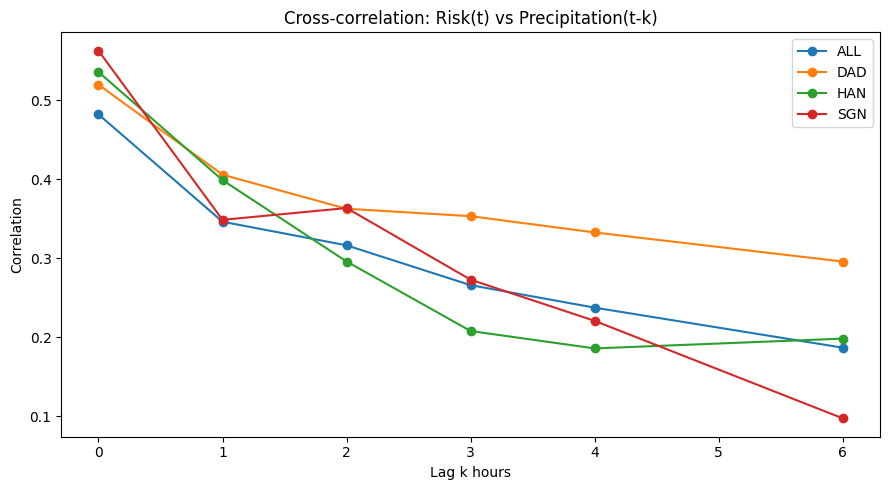

### Best overall lag by absolute correlation

,airport,lag_h,corr_precip_lag_with_risk
0,ALL,0,0.481983


In [27]:
# =========================
# 7. Lag feature validation
# =========================

show_title("7.1. Cross-correlation Risk(t) vs Precipitation(t-k)")

if precip_col is not None:
    lags = [0, 1, 2, 3, 4, 6]
    lag_rows = []

    for lag in lags:
        lag_col = f"{precip_col}_lag_{lag}h_AUTO"
        df[lag_col] = df.groupby(airport_col)[precip_col].shift(lag)

        # Overall
        overall_corr = df[[lag_col, risk_col]].corr().iloc[0, 1]
        lag_rows.append({
            "airport": "ALL",
            "lag_h": lag,
            "corr_precip_lag_with_risk": overall_corr,
        })

        # By airport
        for airport, g in df.groupby(airport_col):
            corr = g[[lag_col, risk_col]].corr().iloc[0, 1]
            lag_rows.append({
                "airport": airport,
                "lag_h": lag,
                "corr_precip_lag_with_risk": corr,
            })

    lag_corr = pd.DataFrame(lag_rows)
    display_and_save(lag_corr, "07_precip_lag_cross_correlation", max_rows=50)

    plt.figure(figsize=(9, 5))
    for airport, g in lag_corr.groupby("airport"):
        plt.plot(g["lag_h"], g["corr_precip_lag_with_risk"], marker="o", label=str(airport))
    plt.title("Cross-correlation: Risk(t) vs Precipitation(t-k)")
    plt.xlabel("Lag k hours")
    plt.ylabel("Correlation")
    plt.legend()
    save_fig("07_precip_lag_cross_correlation.png")
    plt.show()

    best_lag = (
        lag_corr.loc[lag_corr["airport"].eq("ALL")]
                .sort_values("corr_precip_lag_with_risk", key=lambda s: s.abs(), ascending=False)
                .head(1)
    )
    show_title("Best overall lag by absolute correlation")
    display(best_lag)
else:
    print("Không có cột precipitation, bỏ qua cross-correlation.")

### 7.2. Predictive power of precipitation cumulative windows

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/07_precip_cumsum_predictive_power.csv


,feature,airport,corr_with_risk_score,auc_for_risk_gt_0,auc_for_risk_ge_2
0,Precip_Cumsum_1H_Mm,ALL,0.481983,0.965711,0.970664
1,Precip_Cumsum_1H_Mm,DAD,0.519508,0.932593,0.983324
2,Precip_Cumsum_1H_Mm,HAN,0.535641,0.982474,1.000000
3,Precip_Cumsum_1H_Mm,SGN,0.562503,0.976103,0.979686
4,Precip_Cumsum_3H_Mm,ALL,0.496037,0.943993,0.982103
5,Precip_Cumsum_3H_Mm,DAD,0.528704,0.914324,0.981875
6,Precip_Cumsum_3H_Mm,HAN,0.503992,0.950037,0.999547
7,Precip_Cumsum_3H_Mm,SGN,0.574698,0.962250,0.987602
8,Precip_Cumsum_6H_Mm,ALL,0.473796,0.915091,0.974158
9,Precip_Cumsum_6H_Mm,DAD,0.531751,0.894028,0.972074


Saved figure: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/figures/07_precip_cumsum_corr_compare.png


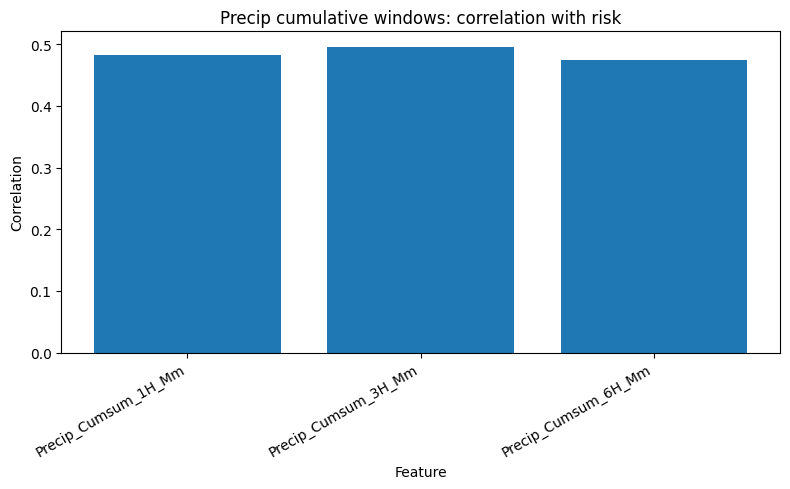

In [28]:
# =========================
# 7.2. Predictive power: Precip_Cumsum 1H vs 3H vs 6H
# =========================

show_title("7.2. Predictive power of precipitation cumulative windows")

try:
    from sklearn.metrics import roc_auc_score
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

cumsum_cols = []
for key in ["precip_cumsum_1h", "precip_cumsum_3h", "precip_cumsum_6h"]:
    col = COLS.get(key)
    if col is not None and col in df.columns:
        cumsum_cols.append(col)

def safe_auc(y_true, y_score):
    y_true = pd.Series(y_true).astype(int)
    y_score = pd.Series(y_score)
    mask = y_true.notna() & y_score.notna()
    y_true = y_true[mask]
    y_score = y_score[mask]
    if y_true.nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

if cumsum_cols:
    rows = []
    y_bin = (df[risk_col] > 0).astype(int)
    y_extreme = (df[risk_col] >= 2).astype(int)

    for col in cumsum_cols:
        rows.append({
            "feature": col,
            "airport": "ALL",
            "corr_with_risk_score": df[[col, risk_col]].corr().iloc[0, 1],
            "auc_for_risk_gt_0": safe_auc(y_bin, df[col]) if SKLEARN_AVAILABLE else np.nan,
            "auc_for_risk_ge_2": safe_auc(y_extreme, df[col]) if SKLEARN_AVAILABLE else np.nan,
        })

        for airport, g in df.groupby(airport_col):
            rows.append({
                "feature": col,
                "airport": airport,
                "corr_with_risk_score": g[[col, risk_col]].corr().iloc[0, 1],
                "auc_for_risk_gt_0": safe_auc((g[risk_col] > 0).astype(int), g[col]) if SKLEARN_AVAILABLE else np.nan,
                "auc_for_risk_ge_2": safe_auc((g[risk_col] >= 2).astype(int), g[col]) if SKLEARN_AVAILABLE else np.nan,
            })

    pred_power = pd.DataFrame(rows)
    display_and_save(pred_power, "07_precip_cumsum_predictive_power", max_rows=50)

    overall_pred = pred_power[pred_power["airport"] == "ALL"].set_index("feature")
    plt.figure(figsize=(8, 5))
    plt.bar(overall_pred.index, overall_pred["corr_with_risk_score"])
    plt.title("Precip cumulative windows: correlation with risk")
    plt.xlabel("Feature")
    plt.ylabel("Correlation")
    plt.xticks(rotation=30, ha="right")
    save_fig("07_precip_cumsum_corr_compare.png")
    plt.show()
else:
    print("Không có Precip_Cumsum 1H/3H/6H, bỏ qua so sánh predictive power.")

In [29]:
# =========================
# 7.3. Temporal autocorrelation / transition probability
# =========================

show_title("7.3. Temporal autocorrelation of bad weather")

df["_risk_bin"] = (df[risk_col] > 0).astype(int)
df["_risk_bin_next"] = df.groupby(airport_col)["_risk_bin"].shift(-1)

transition_rows = []
for airport, g in df.groupby(airport_col):
    valid = g.dropna(subset=["_risk_bin_next"]).copy()
    valid["_risk_bin_next"] = valid["_risk_bin_next"].astype(int)

    p_next_bad_if_now_bad = valid.loc[valid["_risk_bin"] == 1, "_risk_bin_next"].mean()
    p_next_bad_if_now_good = valid.loc[valid["_risk_bin"] == 0, "_risk_bin_next"].mean()

    transition_rows.append({
        "airport": airport,
        "P(next_bad | current_bad)": p_next_bad_if_now_bad,
        "P(next_bad | current_good)": p_next_bad_if_now_good,
        "bad_hours": int((valid["_risk_bin"] == 1).sum()),
        "good_hours": int((valid["_risk_bin"] == 0).sum()),
    })

transition_summary = pd.DataFrame(transition_rows).set_index("airport")
display_and_save(transition_summary, "07_risk_transition_probability")

# Markov transition matrices by airport
for airport, g in df.groupby(airport_col):
    valid = g.dropna(subset=["_risk_bin_next"]).copy()
    valid["_risk_bin_next"] = valid["_risk_bin_next"].astype(int)
    matrix = pd.crosstab(
        valid["_risk_bin"],
        valid["_risk_bin_next"],
        normalize="index"
    )
    matrix.index = ["current_good" if i == 0 else "current_bad" for i in matrix.index]
    matrix.columns = ["next_good" if i == 0 else "next_bad" for i in matrix.columns]
    print(f"\nTransition matrix — {airport}")
    display(matrix)
    matrix.to_csv(REPORT_DIR / f"07_transition_matrix_{airport}.csv")

### 7.3. Temporal autocorrelation of bad weather

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/07_risk_transition_probability.csv


,P(next_bad | current_bad),P(next_bad | current_good),bad_hours,good_hours
airport,,,,
DAD,0.741710,0.090575,573,1634
HAN,0.675241,0.053270,311,1896
SGN,0.639098,0.023144,133,2074



Transition matrix — DAD


,next_good,next_bad
current_good,0.909425,0.090575
current_bad,0.258290,0.741710



Transition matrix — HAN


,next_good,next_bad
current_good,0.946730,0.053270
current_bad,0.324759,0.675241



Transition matrix — SGN


,next_good,next_bad
current_good,0.976856,0.023144
current_bad,0.360902,0.639098


# Bước 8 — Feature quality audit cho ML

Mục tiêu:
- Drop zero-variance feature.
- Kiểm tra near-zero variance.
- Kiểm tra redundancy / multicollinearity.
- Kiểm tra mismatch giữa `Runway_Wet_Risk` và `Is_Rain`.
- Tạo danh sách feature nên drop trước khi join với flight data.

In [30]:
# =========================
# 8. Feature quality audit
# =========================

show_title("8.1. Redundancy check: highly correlated feature pairs")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_abs = df[numeric_cols].corr(numeric_only=True).abs()

upper_mask = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
upper = corr_abs.where(upper_mask)

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
         .sort_values("abs_corr", ascending=False)
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_corr"] >= 0.90]
display_and_save(high_corr_pairs, "08_high_correlation_pairs", max_rows=50)

### 8.1. Redundancy check: highly correlated feature pairs

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/08_high_correlation_pairs.csv


,feature_1,feature_2,abs_corr
138,precipitation,precipitation_lag_0h_AUTO,1.000000
1744,Precip_Cumsum_1H_Mm,precipitation_lag_0h_AUTO,1.000000
96,precipitation,Precip_Cumsum_1H_Mm,1.000000
2691,Is_Low_Visibility,Visibility_Below_5000m,1.000000
519,visibility,Visibility_SM,1.000000
1040,Headwind_Kmh,Headwind_Kt,0.999999
235,wind_speed,Wind_Kt,0.999999
1926,Wind_Gust_Estimate_Kmh,Wind_Gust_Estimate_Kt,0.999999
966,Crosswind_Kmh,Crosswind_Kt,0.999999
2000,Crosswind_Max_3H_Kmh,Crosswind_Max_3H_Kt,0.999999


In [31]:
# =========================
# 8.2. Feature audit table
# =========================

show_title("8.2. Feature audit summary")

audit_rows = []
for col in numeric_cols:
    s = df[col]
    non_na = s.dropna()
    top_rate = s.value_counts(dropna=False, normalize=True).iloc[0] if len(s) > 0 else np.nan
    audit_rows.append({
        "feature": col,
        "dtype": str(df[col].dtype),
        "missing_count": int(s.isna().sum()),
        "missing_rate_pct": s.isna().mean() * 100,
        "nunique": int(s.nunique(dropna=False)),
        "top_value_rate_pct": top_rate * 100,
        "min": non_na.min() if len(non_na) else np.nan,
        "max": non_na.max() if len(non_na) else np.nan,
        "mean": non_na.mean() if len(non_na) else np.nan,
        "std": non_na.std() if len(non_na) else np.nan,
    })

feature_audit = pd.DataFrame(audit_rows).sort_values(["nunique", "top_value_rate_pct"], ascending=[True, False])
display_and_save(feature_audit, "08_feature_audit_summary", max_rows=80)

### 8.2. Feature audit summary

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/08_feature_audit_summary.csv


,feature,dtype,missing_count,missing_rate_pct,nunique,top_value_rate_pct,min,max,mean,std
34,Is_Strong_Wind,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
35,Is_Gale_Wind,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
37,Is_Fog,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
38,Is_Dewpoint_Spread_Le_1_5C,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
39,Is_Radiation_Fog_Risk,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
40,Is_WMO_Fog_Code,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
41,Is_WMO_Rain_Code,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
42,Is_WMO_Thunderstorm_Code,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
44,Is_Below_1SM_Visibility,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000
46,Is_Crosswind_15kt,int64,0,0.000000,1,100.000000,0.00,0.00,0.000000,0.000000


In [32]:
# =========================
# 8.3. Runway_Wet_Risk vs Is_Rain mismatch
# =========================

show_title("8.3. Runway_Wet_Risk vs Is_Rain mismatch")

wet_col = COLS["runway_wet_risk"]
rain_col = COLS["is_rain"]

if wet_col is not None and rain_col is not None:
    tmp = df[[airport_col, dt_col, wet_col, rain_col]].copy()
    tmp["_mismatch"] = tmp[wet_col].fillna(-1).astype(int) != tmp[rain_col].fillna(-1).astype(int)
    mismatch = tmp[tmp["_mismatch"]].copy()

    mismatch_summary = (
        mismatch.groupby(airport_col)
                .size()
                .to_frame("mismatch_hours")
    )
    mismatch_summary["total_hours"] = df.groupby(airport_col).size()
    mismatch_summary["mismatch_rate_pct"] = mismatch_summary["mismatch_hours"] / mismatch_summary["total_hours"] * 100

    display_and_save(mismatch_summary, "08_runway_wet_vs_is_rain_mismatch_summary")
    mismatch.to_csv(REPORT_DIR / "08_runway_wet_vs_is_rain_mismatch_rows.csv", index=False)
    display(mismatch.head(30))
else:
    print("Thiếu Runway_Wet_Risk hoặc Is_Rain, bỏ qua mismatch check.")

### 8.3. Runway_Wet_Risk vs Is_Rain mismatch

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/08_runway_wet_vs_is_rain_mismatch_summary.csv


,mismatch_hours,total_hours,mismatch_rate_pct
Airport,,,
DAD,1,2208,0.045290
HAN,1,2208,0.045290
SGN,7,2208,0.317029


,Airport,time,Runway_Wet_Risk,Is_Rain,_mismatch
1888,DAD,2026-03-03 16:00:00,2,1,True
2621,HAN,2026-01-01 05:00:00,2,1,True
4670,SGN,2025-12-25 14:00:00,2,1,True
4674,SGN,2025-12-25 18:00:00,2,1,True
4959,SGN,2026-01-06 15:00:00,2,1,True
4961,SGN,2026-01-06 17:00:00,2,1,True
6178,SGN,2026-02-26 10:00:00,2,1,True
6204,SGN,2026-02-27 12:00:00,2,1,True
6207,SGN,2026-02-27 15:00:00,2,1,True


In [33]:
# =========================
# 8.4. Suggested drop list before ML / flight join
# =========================

show_title("8.4. Suggested feature drop list")

suggested_drop = set()
reason_rows = []

# Zero variance
for col in zero_variance.index.tolist():
    suggested_drop.add(col)
    reason_rows.append({"feature": col, "reason": "zero_variance"})

# Is_Fog logic issue: all zero but low visibility exists
fog_col = COLS["is_fog"]
lowvis_col = COLS["is_low_visibility"]
if fog_col is not None and lowvis_col is not None:
    fog_sum = df[fog_col].fillna(0).sum()
    lowvis_sum = df[lowvis_col].fillna(0).sum()
    if fog_sum == 0 and lowvis_sum > 0:
        suggested_drop.add(fog_col)
        reason_rows.append({
            "feature": fog_col,
            "reason": "logic_review_needed: fog all zero while low visibility exists"
        })

# Visibility raw nếu cap quá nặng
if vis_col is not None and "Visibility_Capped_Flag" in df.columns:
    cap_rate = df["Visibility_Capped_Flag"].mean()
    if cap_rate >= 0.80:
        reason_rows.append({
            "feature": vis_col,
            "reason": f"consider_drop_or_replace: raw visibility heavily capped ({cap_rate*100:.1f}%). Prefer threshold flags."
        })

# Near-zero variance: gợi ý review, không auto drop toàn bộ
if len(near_zero_variance) > 0:
    for col in near_zero_variance["feature"].tolist():
        if col not in suggested_drop:
            reason_rows.append({
                "feature": col,
                "reason": "review_near_zero_variance"
            })

drop_recommendation = (
    pd.DataFrame(reason_rows)
      .drop_duplicates()
      .sort_values(["reason", "feature"])
      .reset_index(drop=True)
)

display_and_save(drop_recommendation, "08_suggested_drop_or_review_features", max_rows=100)

print("\nSuggested hard-drop features:")
display(pd.DataFrame({"feature": sorted(suggested_drop)}))

### 8.4. Suggested feature drop list

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/08_suggested_drop_or_review_features.csv


,feature,reason
0,visibility,consider_drop_or_replace: raw visibility heavi...
1,Is_Fog,logic_review_needed: fog all zero while low vi...
2,Is_Below_3SM_Visibility,review_near_zero_variance
3,Is_Extreme_Heat,review_near_zero_variance
4,Is_Heavy_Rain,review_near_zero_variance
5,Is_Low_Visibility,review_near_zero_variance
6,Visibility_Deficit_3SM_M,review_near_zero_variance
7,Visibility_Deficit_5KM_M,review_near_zero_variance
8,Visibility_Severity_Score,review_near_zero_variance
9,Convective_Severity_Score,zero_variance



Suggested hard-drop features:


,feature
0,Convective_Severity_Score
1,Is_Below_1SM_Visibility
2,Is_Crosswind_15kt
3,Is_Crosswind_20kt
4,Is_Dewpoint_Spread_Le_1_5C
5,Is_Fog
6,Is_Freezing
7,Is_Gale_Wind
8,Is_Low_Ceiling_Risk
9,Is_Radiation_Fog_Risk


# Output cuối sau EDA

Cell này tổng hợp:
- Danh sách feature cần drop / review.
- Lag window tốt nhất theo correlation.
- Airport-specific thresholds.
- Imbalance ratio.
- Seasonal index airport × month.

In [34]:
# =========================
# 9. Final EDA outputs
# =========================

show_title("9.1. Seasonal index: airport × month")

overall_risk_mean = df[risk_col].mean()
seasonal_index = monthly.copy()
seasonal_index["risk_index_vs_overall"] = seasonal_index["risk_mean"] / overall_risk_mean if overall_risk_mean != 0 else np.nan
display_and_save(seasonal_index, "09_seasonal_index_airport_month", max_rows=50)

show_title("9.2. Final summary")

summary_items = []

# dataset
summary_items.append(f"Rows: {len(df):,}")
summary_items.append(f"Columns: {df.shape[1]:,}")
summary_items.append(f"Airports: {df[airport_col].nunique()}")

# time
summary_items.append(f"Time range: {df[dt_col].min()} → {df[dt_col].max()}")

# target
summary_items.append(f"Risk > 0 rate: {(df[risk_col] > 0).mean() * 100:.2f}%")
summary_items.append(f"Risk >= 2 rate: {(df[risk_col] >= 2).mean() * 100:.2f}%")

# visibility cap
if vis_col is not None:
    summary_items.append(f"Visibility capped rate: {df['Visibility_Capped_Flag'].mean() * 100:.2f}%")

# best lag
if "lag_corr" in globals() and precip_col is not None:
    best = (
        lag_corr.loc[lag_corr["airport"].eq("ALL")]
                .sort_values("corr_precip_lag_with_risk", key=lambda s: s.abs(), ascending=False)
                .head(1)
    )
    if len(best):
        summary_items.append(
            f"Best precip lag overall: {int(best['lag_h'].iloc[0])}h "
            f"(corr={best['corr_precip_lag_with_risk'].iloc[0]:.3f})"
        )

for item in summary_items:
    print("-", item)

final_summary = pd.DataFrame({"summary": summary_items})
final_summary.to_csv(REPORT_DIR / "09_final_summary.csv", index=False)

print(f"\nTất cả bảng và hình đã lưu trong: {REPORT_DIR.resolve()}")

### 9.1. Seasonal index: airport × month

Saved table: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports/09_seasonal_index_airport_month.csv


,Airport,_month,hours,risk_mean,risk_positive_rate_pct,risk_ge2_rate_pct,precip_mean,precip_sum,rain_rate_pct,thunderstorm_rate_pct,risk_index_vs_overall
0,DAD,2025-12,408,0.512255,51.225490,0.000000,0.267647,109.2,66.911765,50.980392,3.272108
1,DAD,2026-01,744,0.151882,15.188172,0.000000,0.075134,55.9,29.838710,15.188172,0.970168
2,DAD,2026-02,672,0.183036,18.303571,0.000000,0.073810,49.6,27.976190,18.303571,1.169169
3,DAD,2026-03,384,0.354167,33.333333,2.083333,0.253906,97.5,54.166667,33.072917,2.262295
4,HAN,2025-12,408,0.093137,9.313725,0.000000,0.040686,16.6,16.421569,9.313725,0.594929
5,HAN,2026-01,744,0.130376,12.903226,0.134409,0.069892,52.0,15.725806,12.903226,0.832799
6,HAN,2026-02,672,0.205357,20.535714,0.000000,0.076786,51.6,22.470238,20.535714,1.311751
7,HAN,2026-03,384,0.101562,10.156250,0.000000,0.041146,15.8,11.979167,10.156250,0.648746
8,SGN,2025-12,408,0.125000,11.029412,1.225490,0.098775,40.3,14.705882,11.029412,0.798457
9,SGN,2026-01,744,0.028226,2.553763,0.268817,0.037769,28.1,4.435484,2.553763,0.180297


### 9.2. Final summary

- Rows: 6,624
- Columns: 82
- Airports: 3
- Time range: 2025-12-15 00:00:00 → 2026-03-16 23:00:00
- Risk > 0 rate: 15.35%
- Risk >= 2 rate: 0.29%
- Visibility capped rate: 83.74%
- Best precip lag overall: 0h (corr=0.482)

Tất cả bảng và hình đã lưu trong: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/eda_weather_reports


## Gợi ý đọc kết quả

Sau khi chạy xong notebook, bạn nên lấy các file sau để đưa vào báo cáo:

- `01_visibility_capping_by_airport.csv`: chứng minh artifact visibility cap.
- `02_monthly_profile.csv`: seasonal risk theo sân bay × tháng.
- `03_corr_with_risk.csv`: top feature liên quan risk score.
- `04_airport_profile.csv`: so sánh profile từng sân bay.
- `05_imbalance_summary.csv`: imbalance ratio để justify SMOTE/oversampling sau này.
- `06_visibility_threshold_summary.csv`: low visibility theo threshold 10,000m / 5,000m / 3,000m.
- `07_precip_lag_cross_correlation.csv`: xác nhận lag window tối ưu.
- `08_suggested_drop_or_review_features.csv`: danh sách feature drop/review trước khi join flight data.
- `09_seasonal_index_airport_month.csv`: calendar feature cho model sau này.